<a href="https://colab.research.google.com/github/linneverh/Sust-Finance/blob/Assignment-2/Homework_2_Daniel_290320.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment: Portfolio Allocation based on Financial Performance**

In [ ]:
# Import packages

# installing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import calendar
import yfinance as yf
import scipy.optimize as sco
import scipy.interpolate as sci
import matplotlib.pyplot as plt
import cvxpy as cp
#from pypfopt.efficient_frontier import EfficientFrontier
#from pypfopt import risk_models
#from pypfopt import expected_returns
from datetime import datetime, timedelta
from scipy.optimize import minimize
#from pypfopt.objective_functions import portfolio_return
from tqdm import tqdm

In [ ]:
#import dataset from git
url_DS_ESGScore_Y = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_ESGScore_Y.csv'
DS_ESGScore_Y = pd.read_csv(url_DS_ESGScore_Y)

url_DS_EScore_Y = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_EScore_Y.csv'
DS_EScore_Y = pd.read_csv(url_DS_EScore_Y)

url_DS_MV_USD_M = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_MV_USD_M.csv'
DS_MV_USD_M = pd.read_csv(url_DS_MV_USD_M)

url_DS_MV_USD_Y = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_MV_USD_Y.csv'
DS_MV_USD_Y = pd.read_csv(url_DS_MV_USD_Y)

url_DS_REV_USD_Y = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_REV_USD_Y.csv'
DS_REV_USD_Y = pd.read_csv(url_DS_REV_USD_Y)

url_DS_RI_USD_M = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_RI_USD_M.csv'
DS_RI_USD_M = pd.read_csv(url_DS_RI_USD_M)

url_DS_RI_USD_Y = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_RI_USD_Y.csv'
DS_RI_USD_Y = pd.read_csv(url_DS_RI_USD_M)

url_Risk_Free_Rate = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/Risk_Free_Rate.csv'
Risk_Free_Rate = pd.read_csv(url_Risk_Free_Rate)

url_Static = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/Static.csv'
Static = pd.read_csv(url_Static)


<ipython-input-2-ab90805fdee2>:9: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  DS_MV_USD_M = pd.read_csv(url_DS_MV_USD_M)


## Cleaning

### Return index and percentage data frame

#### MERGING RETURNS TABLE AND ESCORE TABLE FOR EM COUNTRIES

In [ ]:
# Merging the data to filter per region
merged_DS_RI_USD_M = pd.merge(DS_RI_USD_M, Static, on='ISIN', how='inner')
merged_DS_RI_USD_M = merged_DS_RI_USD_M[['ISIN', 'Name', 'Country', 'Region'] + [col for col in merged_DS_RI_USD_M.columns if col not in ['ISIN', 'Name', 'Country', 'Region']]]
del(merged_DS_RI_USD_M['NAME'])

#Keeping only the columns between 30/01/04 and 31/12/24
start_date = pd.to_datetime('2008-12-31')
end_date = pd.to_datetime('2024-12-31')

# Filter columns excluding non-date columns
date_columns = [col for col in merged_DS_RI_USD_M.columns if col not in ['ISIN', 'Name', 'Country', 'Region'] and start_date <= pd.to_datetime(col, errors='ignore') <= end_date]
selected_columns = ['ISIN', 'Name', 'Country', 'Region'] + date_columns
merged_DS_RI_USD_M = merged_DS_RI_USD_M[selected_columns]
#merged_DS_RI_USD_M.head()


# Filter on EM countries
EM_merged_DS_RI_USD_M = merged_DS_RI_USD_M[merged_DS_RI_USD_M['Region'] == 'EM']
EM_merged_DS_RI_USD_M

<ipython-input-3-feee87fa7c77>:11: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  date_columns = [col for col in merged_DS_RI_USD_M.columns if col not in ['ISIN', 'Name', 'Country', 'Region'] and start_date <= pd.to_datetime(col, errors='ignore') <= end_date]


,ISIN,Name,Country,Region,2008-12-31 00:00:00,2009-01-30 00:00:00,2009-02-27 00:00:00,2009-03-31 00:00:00,2009-04-30 00:00:00,2009-05-29 00:00:00,...,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00
1,ARALUA010258,ALUAR,AR,EM,1742.20,1638.06,1242.49,1130.96,1270.87,1450.59,...,5760.96,5331.65,6253.43,5993.00,5680.53,5323.94,4928.66,4706.05,5207.18,4802.89
2,ARP125991090,BANCO BBVA ARGENTINA,AR,EM,73.66,63.74,51.65,60.00,68.34,96.48,...,412.77,458.42,672.82,624.64,569.69,669.66,637.87,774.26,885.63,1067.88
3,ARSIDE010029,TERNIUM ARGENTINA SOCIEDAD ANONIMA,AR,EM,198.77,172.44,129.34,121.38,113.08,117.02,...,1182.67,1092.52,1295.37,1215.48,1155.27,999.71,974.26,916.65,1076.94,982.55
118,BMG211591018,CHINA YURUN FOOD GROUP,CN,EM,32.48,32.78,32.71,35.23,32.91,38.78,...,0.63,0.59,0.59,0.56,0.51,0.59,0.62,0.80,0.67,0.63
146,BRABEVACNOR1,AMBEV ON,BR,EM,394.23,377.41,385.15,439.05,499.37,600.61,...,1199.78,1127.14,1057.57,987.73,985.01,1091.85,1154.89,1049.92,1025.18,963.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,ZAE000191342,ALTRON LIMITED A,ZA,EM,118.52,113.91,93.10,102.74,126.74,139.73,...,103.80,108.05,121.84,131.64,173.36,175.55,184.07,190.50,209.13,210.60
2561,ZAE000255915,ABSA GROUP,ZA,EM,229.96,179.19,174.18,206.75,237.39,258.24,...,373.17,386.72,396.75,434.53,439.89,495.99,531.01,497.48,498.09,524.49
2562,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,16.97,13.06,16.55,20.93,25.86,32.95,...,53.35,59.43,61.64,62.37,70.16,53.12,56.97,66.32,56.06,46.48
2563,ZAE000302618,AVENG,ZA,EM,68.95,53.69,53.19,56.84,80.05,90.09,...,0.05,0.05,0.05,0.06,0.08,0.09,0.09,0.08,0.10,0.10


#### Creation of R at wrong position

In [ ]:
# Merging the EScore to EM, from 2003 to 2023

merged_DS_EScore_Y = pd.merge(DS_EScore_Y, Static, on='ISIN', how='inner')
merged_DS_EScore_Y = merged_DS_EScore_Y[['ISIN', 'Name', 'Region'] + [col for col in merged_DS_EScore_Y.columns if col not in ['ISIN', 'Name', 'Region', 'NAME']]]

#Keeping only the columns between 31/12/03 and 31/12/23
start_date = pd.to_datetime('2008-12-31')
end_date = pd.to_datetime('2023-12-31')

# Filter columns excluding non-date columns
date_columns = [col for col in merged_DS_EScore_Y.columns if col not in ['ISIN', 'Name', 'Country', 'Region'] and start_date <= pd.to_datetime(col, errors='ignore') <= end_date]
selected_columns = ['ISIN', 'Name', 'Country', 'Region'] + date_columns
merged_DS_EScore_Y = merged_DS_EScore_Y[selected_columns]


# Filter on EM countries
EM_merged_DS_EScore_Y = merged_DS_EScore_Y[merged_DS_EScore_Y['Region'] == 'EM']
EM_merged_DS_EScore_Y

<ipython-input-4-d041599f5589>:11: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  date_columns = [col for col in merged_DS_EScore_Y.columns if col not in ['ISIN', 'Name', 'Country', 'Region'] and start_date <= pd.to_datetime(col, errors='ignore') <= end_date]


,ISIN,Name,Country,Region,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
1,ARALUA010258,ALUAR,AR,EM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.82,13.26,12.26,11.05,13.19,12.21,17.65
2,ARP125991090,BANCO BBVA ARGENTINA,AR,EM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.51,56.64,76.16,84.68,82.48,88.36,86.99,79.68
3,ARSIDE010029,TERNIUM ARGENTINA SOCIEDAD ANONIMA,AR,EM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.51,33.47,33.72,33.41,33.52,38.37,36.83,48.05
118,BMG211591018,CHINA YURUN FOOD GROUP,CN,EM,0.0,0.00,0.00,0.00,0.00,0.00,0.00,17.85,36.12,45.19,48.35,52.97,63.43,53.70,47.78
145,BRABEVACNOR1,AMBEV ON,BR,EM,NaN,NaN,NaN,NaN,57.38,58.81,66.63,74.17,67.08,55.27,68.85,72.11,77.48,67.51,62.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2503,ZAE000191342,ALTRON LIMITED A,ZA,EM,NaN,NaN,NaN,43.78,44.42,54.31,56.78,59.55,57.53,30.93,30.08,27.51,38.62,31.87,37.06
2504,ZAE000255915,ABSA GROUP,ZA,EM,52.2,53.90,48.96,58.02,56.43,55.56,68.94,75.90,81.90,80.63,83.03,81.99,81.45,79.12,84.75
2505,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,NaN,60.96,53.53,59.07,54.34,54.03,52.42,56.64,53.90,63.37,62.03,67.79,73.50,74.37,63.96
2506,ZAE000302618,AVENG,ZA,EM,NaN,58.89,62.27,78.98,72.99,64.66,69.09,70.85,52.33,45.73,44.32,44.52,48.95,31.21,25.61


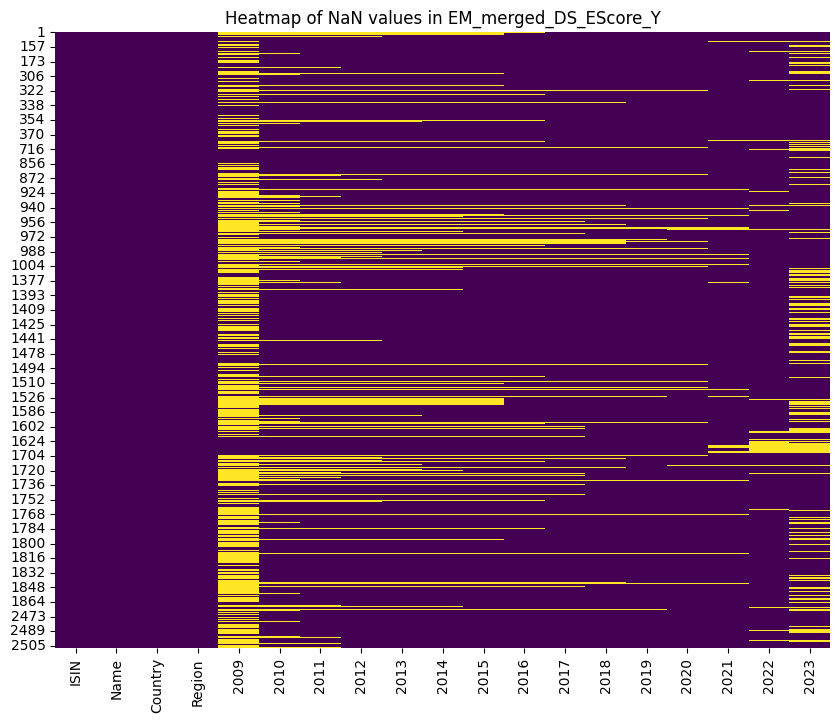

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(EM_merged_DS_EScore_Y.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of NaN values in EM_merged_DS_EScore_Y')
plt.show()

In [ ]:
# Filling in missing ESG
df_filled = EM_merged_DS_EScore_Y.copy()

# Identify the year columns (assuming they are strings representing years)
year_columns = sorted([col for col in df_filled.columns if col.isdigit()])

# Iterate through the year columns
for i in range(1, len(year_columns)):
    prev_year = year_columns[i-1]
    current_year = year_columns[i]

    # Create a mask to select rows where:
    # 1. The current year is NaN
    # 2. The previous year is NOT NaN
    # 3. The previous year's value is a float
    mask = (df_filled[current_year].isna()) & \
           (df_filled[prev_year].notna()) & \
           (df_filled[prev_year].apply(lambda x: isinstance(x, (int, float)))) #check if int or float (not only float)

    # Fill the NaN values in the current year with the previous year's float value
    df_filled.loc[mask, current_year] = df_filled.loc[mask, prev_year]

# Update DS_ESGScore_Y_filtered with the filled values
EM_merged_DS_EScore_Y = df_filled

In [ ]:
#FILTERING ONLY FIRMS WITH AN E SCORE FROM 2013 ON

# Remplacer les chaînes de caractères "NaN" par np.nan
EM_merged_DS_EScore_Y = EM_merged_DS_EScore_Y.replace('NaN', np.nan)
EM_merged_DS_EScore_Y = EM_merged_DS_EScore_Y.replace(0, np.nan)

# Convert date columns to datetime if they are not already
date_columns = EM_merged_DS_EScore_Y.columns[4:]  # Assuming 'ISIN', 'Name', 'Country', 'Region' are the first 4 columns
EM_merged_DS_EScore_Y.columns = EM_merged_DS_EScore_Y.columns[:4].tolist() + pd.to_datetime(date_columns, errors='coerce').tolist()

# Select columns from 2013 onwards
start_date = pd.to_datetime('2013-12-31')
date_columns_2013_onwards = [col for col in EM_merged_DS_EScore_Y.columns
                             if isinstance(col, pd.Timestamp) and col >= start_date]

# Filter for rows with no NaN values in the selected columns
EM_merged_DS_EScore_Y = EM_merged_DS_EScore_Y[
    EM_merged_DS_EScore_Y[date_columns_2013_onwards].notna().all(axis=1)
]
EM_merged_DS_EScore_Y

,ISIN,Name,Country,Region,2009-01-01 00:00:00,2010-01-01 00:00:00,2011-01-01 00:00:00,2012-01-01 00:00:00,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2017-01-01 00:00:00,2018-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00
145,BRABEVACNOR1,AMBEV ON,BR,EM,NaN,NaN,NaN,NaN,57.38,58.81,66.63,74.17,67.08,55.27,68.85,72.11,77.48,67.51,62.78
146,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,68.98,87.93,85.72,87.23,89.93,90.21,91.78,94.54,94.64,94.43,94.44,91.44,91.20,92.86,93.30
147,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,78.70,84.85,86.45,81.49,80.31,83.16,88.79,95.72,96.06,96.32,95.57,94.90,95.52,94.60,97.80
148,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,53.61,42.42,65.34,77.78,75.80,78.70,75.73,77.90,77.55,77.98,72.71,77.44,81.78,82.94,82.34
149,BRBRKMACNPA4,BRASKEM PN A,BR,EM,58.64,58.57,61.40,57.79,57.57,41.05,44.03,43.06,50.40,53.56,49.96,50.09,51.08,48.23,50.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2503,ZAE000191342,ALTRON LIMITED A,ZA,EM,NaN,NaN,NaN,43.78,44.42,54.31,56.78,59.55,57.53,30.93,30.08,27.51,38.62,31.87,37.06
2504,ZAE000255915,ABSA GROUP,ZA,EM,52.20,53.90,48.96,58.02,56.43,55.56,68.94,75.90,81.90,80.63,83.03,81.99,81.45,79.12,84.75
2505,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,NaN,60.96,53.53,59.07,54.34,54.03,52.42,56.64,53.90,63.37,62.03,67.79,73.50,74.37,63.96
2506,ZAE000302618,AVENG,ZA,EM,NaN,58.89,62.27,78.98,72.99,64.66,69.09,70.85,52.33,45.73,44.32,44.52,48.95,31.21,25.61


#### Restricting RI to countries with E-Score

In [ ]:
isin_list = EM_merged_DS_EScore_Y['ISIN'].tolist()

# Filter EM_merged_DS_R_USD_M to keep only rows with ISINs present in the list
filtered_EM_merged_DS_RI_USD_M = EM_merged_DS_RI_USD_M[EM_merged_DS_RI_USD_M['ISIN'].isin(isin_list)].copy()
filtered_EM_merged_DS_RI_USD_M

,ISIN,Name,Country,Region,2008-12-31 00:00:00,2009-01-30 00:00:00,2009-02-27 00:00:00,2009-03-31 00:00:00,2009-04-30 00:00:00,2009-05-29 00:00:00,...,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00
146,BRABEVACNOR1,AMBEV ON,BR,EM,394.23,377.41,385.15,439.05,499.37,600.61,...,1199.78,1127.14,1057.57,987.73,985.01,1091.85,1154.89,1049.92,1025.18,963.62
147,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,245.54,238.41,232.53,295.41,343.13,434.93,...,1272.70,1190.47,1161.15,1109.30,1083.48,1164.81,1178.58,1074.08,998.11,947.95
148,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,1045.32,969.65,946.95,1094.17,1366.23,1686.93,...,1893.69,1797.94,1607.05,1495.68,1489.17,1884.13,1854.74,1719.88,1477.92,1316.83
149,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,1499.44,1619.46,1465.67,1468.26,1748.31,2339.82,...,902.28,901.27,978.31,1129.50,1031.04,1281.75,1201.84,1253.98,1177.39,1168.17
150,BRBRKMACNPA4,BRASKEM PN A,BR,EM,130.15,134.40,123.86,114.25,155.57,198.78,...,497.04,386.92,338.89,303.03,292.59,300.20,344.89,285.88,236.76,176.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,ZAE000191342,ALTRON LIMITED A,ZA,EM,118.52,113.91,93.10,102.74,126.74,139.73,...,103.80,108.05,121.84,131.64,173.36,175.55,184.07,190.50,209.13,210.60
2561,ZAE000255915,ABSA GROUP,ZA,EM,229.96,179.19,174.18,206.75,237.39,258.24,...,373.17,386.72,396.75,434.53,439.89,495.99,531.01,497.48,498.09,524.49
2562,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,16.97,13.06,16.55,20.93,25.86,32.95,...,53.35,59.43,61.64,62.37,70.16,53.12,56.97,66.32,56.06,46.48
2563,ZAE000302618,AVENG,ZA,EM,68.95,53.69,53.19,56.84,80.05,90.09,...,0.05,0.05,0.05,0.06,0.08,0.09,0.09,0.08,0.10,0.10


In [ ]:
rows_with_nans = EM_merged_DS_EScore_Y[EM_merged_DS_EScore_Y.isnull().any(axis=1)]
nan_counts_per_row = rows_with_nans.isnull().sum(axis=1)
df_nan_rows = pd.DataFrame({'Row': rows_with_nans.index, 'Nan_Count': nan_counts_per_row})

df_nan_rows

,Row,Nan_Count
145,145,4
151,151,1
154,154,1
155,155,1
157,157,1
...,...,...
2502,2502,1
2503,2503,3
2505,2505,1
2506,2506,1


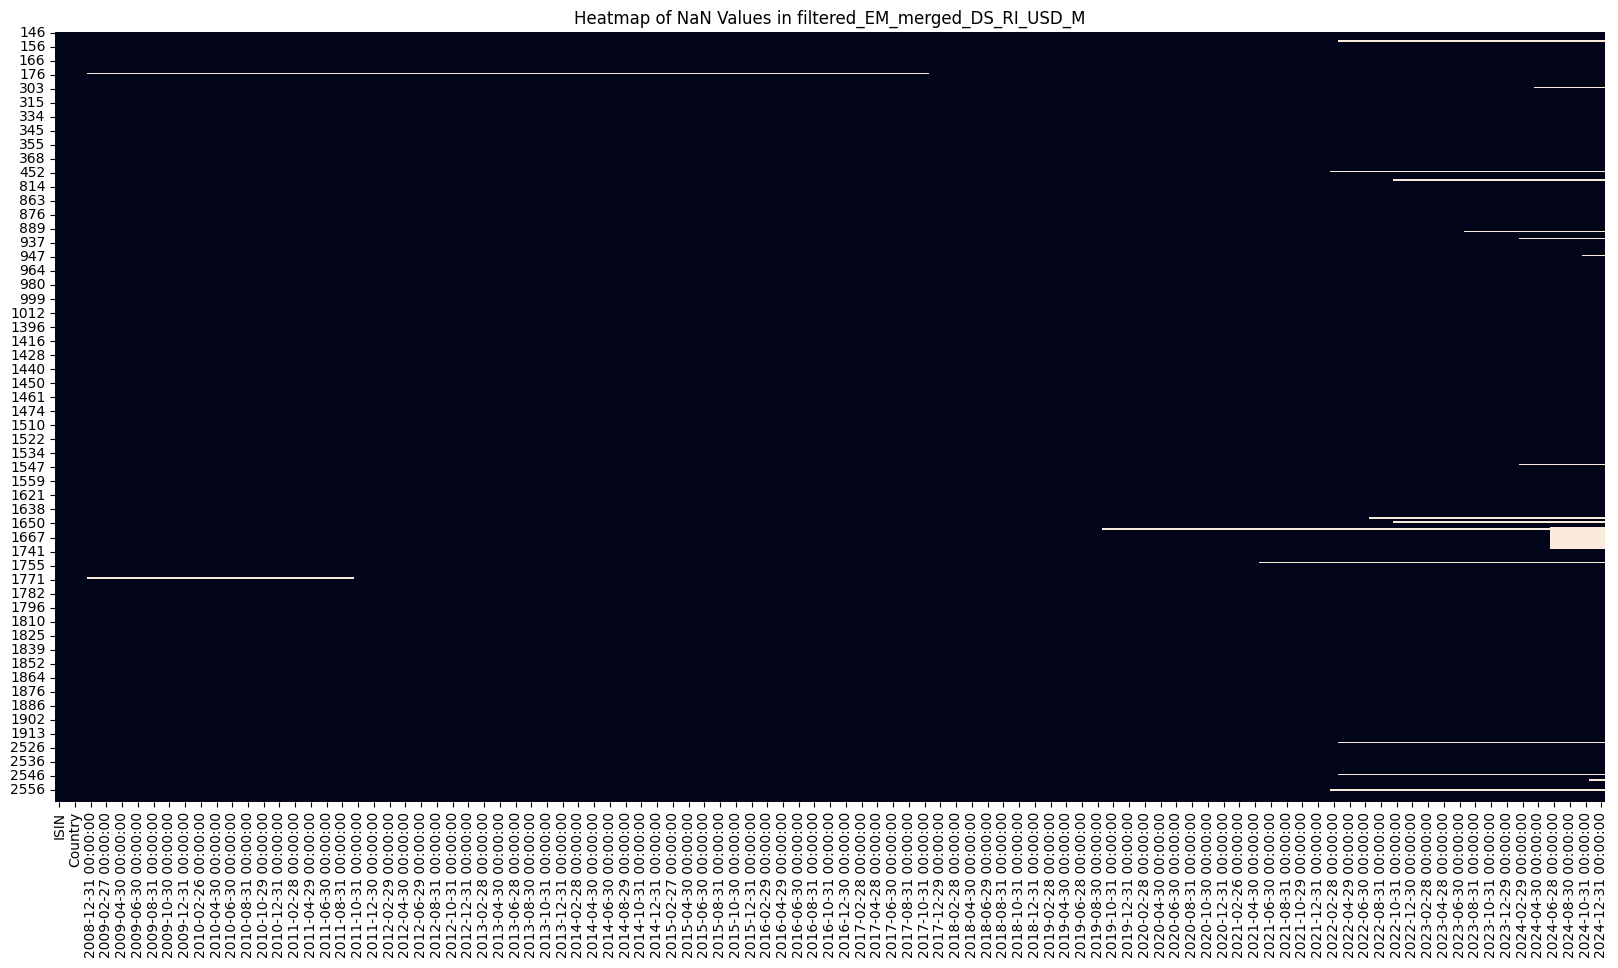

In [ ]:
plt.figure(figsize=(20, 10))  # Adjust figure size as needed
sns.heatmap(filtered_EM_merged_DS_RI_USD_M.isnull(), cbar=False)
plt.title('Heatmap of NaN Values in filtered_EM_merged_DS_RI_USD_M')
plt.show()

#### HATZOLD RULE: NAN VALUES BETWEEN 2014 AND 2024

In [ ]:
import pandas as pd
import numpy as np

# Make a copy to preserve the original
df_filled = filtered_EM_merged_DS_RI_USD_M.copy()

# Define time series columns (numerical columns across time)
time_cols = [col for col in df_filled.columns if col not in ['ISIN', 'Name', 'Country', 'Region']]

# Function to interpolate isolated NaNs across columns (i.e., along each row)
def interpolate_isolated_row(row):
    values = row.values.copy()
    for i in range(1, len(values) - 1):
        if pd.isna(values[i]) and not pd.isna(values[i - 1]) and not pd.isna(values[i + 1]):
            values[i] = (values[i - 1] + values[i + 1]) / 2
    return pd.Series(values, index=row.index)

# Apply row-wise interpolation only on the time columns
df_filled[time_cols] = df_filled[time_cols].apply(interpolate_isolated_row, axis=1)

# Optionally update the original DataFrame
filtered_EM_merged_DS_RI_USD_M = df_filled

In [ ]:
filtered_EM_merged_DS_RI_USD_M

,ISIN,Name,Country,Region,2008-12-31 00:00:00,2009-01-30 00:00:00,2009-02-27 00:00:00,2009-03-31 00:00:00,2009-04-30 00:00:00,2009-05-29 00:00:00,...,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00
146,BRABEVACNOR1,AMBEV ON,BR,EM,394.23,377.41,385.15,439.05,499.37,600.61,...,1199.78,1127.14,1057.57,987.73,985.01,1091.85,1154.89,1049.92,1025.18,963.62
147,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,245.54,238.41,232.53,295.41,343.13,434.93,...,1272.70,1190.47,1161.15,1109.30,1083.48,1164.81,1178.58,1074.08,998.11,947.95
148,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,1045.32,969.65,946.95,1094.17,1366.23,1686.93,...,1893.69,1797.94,1607.05,1495.68,1489.17,1884.13,1854.74,1719.88,1477.92,1316.83
149,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,1499.44,1619.46,1465.67,1468.26,1748.31,2339.82,...,902.28,901.27,978.31,1129.50,1031.04,1281.75,1201.84,1253.98,1177.39,1168.17
150,BRBRKMACNPA4,BRASKEM PN A,BR,EM,130.15,134.40,123.86,114.25,155.57,198.78,...,497.04,386.92,338.89,303.03,292.59,300.20,344.89,285.88,236.76,176.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,ZAE000191342,ALTRON LIMITED A,ZA,EM,118.52,113.91,93.10,102.74,126.74,139.73,...,103.80,108.05,121.84,131.64,173.36,175.55,184.07,190.50,209.13,210.60
2561,ZAE000255915,ABSA GROUP,ZA,EM,229.96,179.19,174.18,206.75,237.39,258.24,...,373.17,386.72,396.75,434.53,439.89,495.99,531.01,497.48,498.09,524.49
2562,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,16.97,13.06,16.55,20.93,25.86,32.95,...,53.35,59.43,61.64,62.37,70.16,53.12,56.97,66.32,56.06,46.48
2563,ZAE000302618,AVENG,ZA,EM,68.95,53.69,53.19,56.84,80.05,90.09,...,0.05,0.05,0.05,0.06,0.08,0.09,0.09,0.08,0.10,0.10


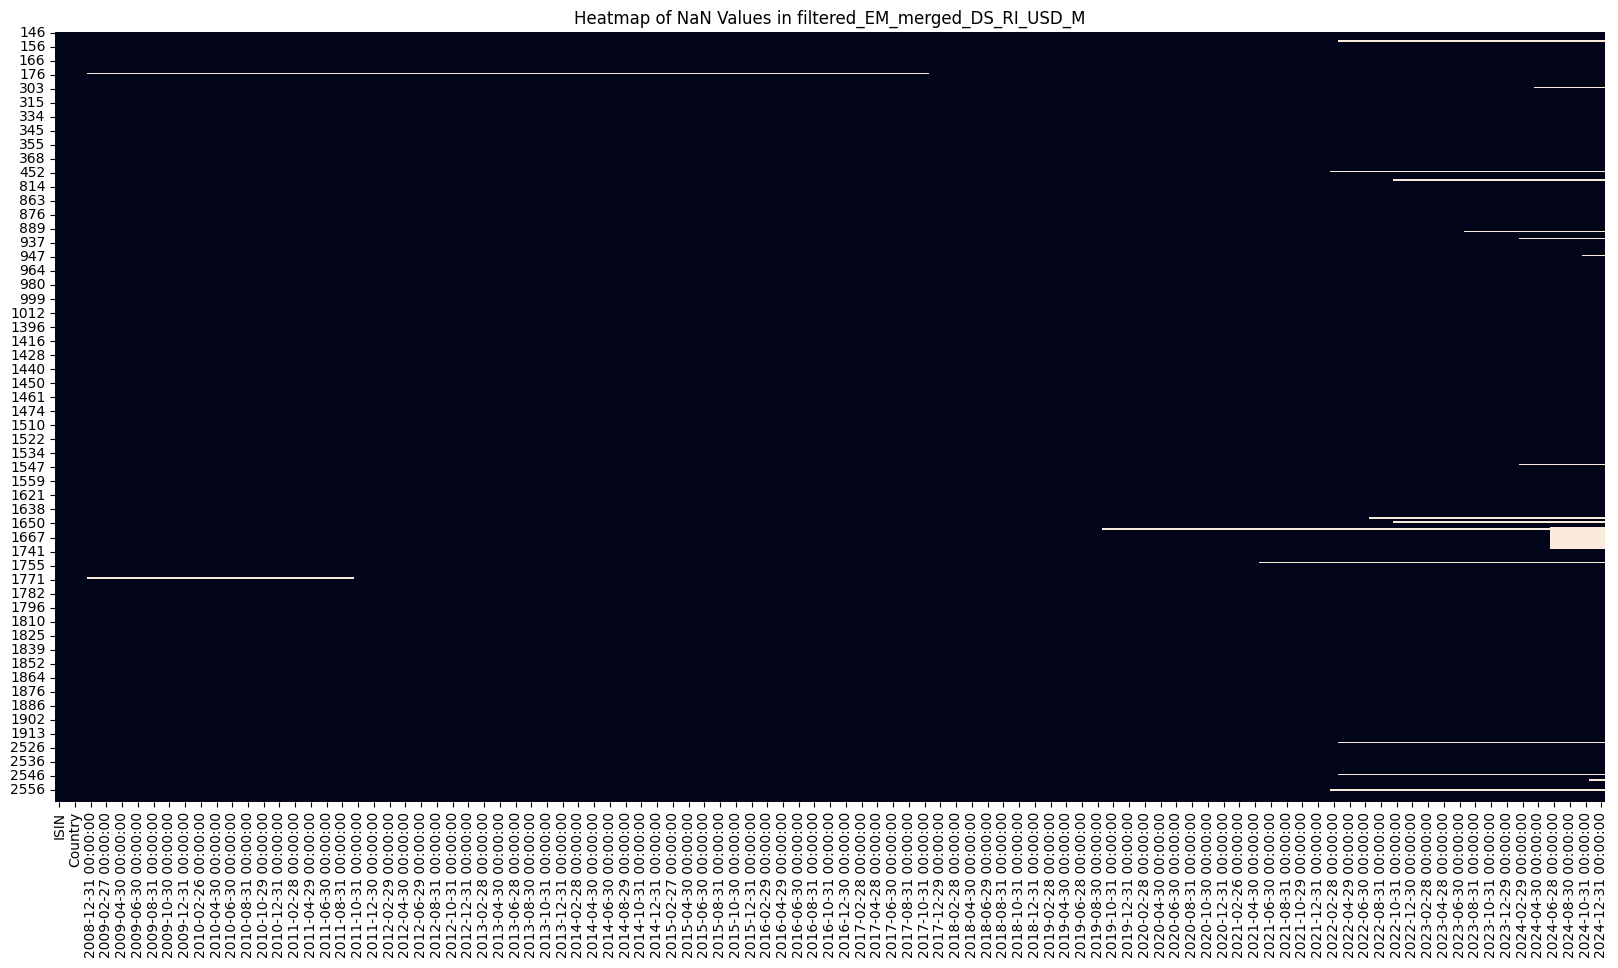

In [ ]:
# prompt: can you create a heat map of nan in filtered_EM_merged_DS_RI_USD_M

plt.figure(figsize=(20, 10))  # Adjust figure size as needed
sns.heatmap(filtered_EM_merged_DS_RI_USD_M.isnull(), cbar=False)
plt.title('Heatmap of NaN Values in filtered_EM_merged_DS_RI_USD_M')
plt.show()


In the following part, we will first try to identify which firms to get rid of because of missing values ( time frame: 2004-2024: correct? )

In [ ]:
# Filter for rows where 'Name' contains "SUSP" or "DELIST"
# Filter for rows where 'Name' contains "SUSP" or "DELIST" and select 'Name' and 'ISIN'
filtered_name_isin = filtered_EM_merged_DS_RI_USD_M[
    filtered_EM_merged_DS_RI_USD_M['Name'].str.contains("SUSP|DELIST", case=False, na=False)
][['Name', 'ISIN']]

filtered_name_isin

,Name,ISIN
152,CMPH.ENGT.DE SAOP.B PN DEAD - DELIST.29/03/22,BRCESPACNPB4
302,AES ANDES DEAD - DELIST.18/04/24,CL0002694637
378,TELF.O2 CZECH REPUBLIC DEAD - DELIST.25/02/22,CZ0009093209
722,LAMPRELL DEAD - DELIST.25/10/22,GB00B1CL5249
934,RELIANCE CAPITAL SUSP - SUSP.29/02/24,INE013A01015
946,IDFC DEAD - DELIST.11/10/24,INE043D01016
1544,UMW HOLDINGS DEAD - DELIST.19/02/24,MYL4588OO009
1646,GRUPA LOTOS DEAD - DELIST.12/08/22,PLLOTOS00025
1649,POLISH OIL AND GAS DEAD - DELIST.18/11/22,PLPGNIG00014
1753,THAI AIRWAYS INTL. SUSP - SUSP.25/03/24,TH0245010002


In [ ]:
isins_to_remove = filtered_name_isin['ISIN'].tolist()

filtered_dead_EM_merged_DS_RI_USD_M = filtered_EM_merged_DS_RI_USD_M[~filtered_EM_merged_DS_RI_USD_M['ISIN'].isin(isins_to_remove)]

filtered_dead_EM_merged_DS_RI_USD_M

,ISIN,Name,Country,Region,2008-12-31 00:00:00,2009-01-30 00:00:00,2009-02-27 00:00:00,2009-03-31 00:00:00,2009-04-30 00:00:00,2009-05-29 00:00:00,...,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00
146,BRABEVACNOR1,AMBEV ON,BR,EM,394.23,377.41,385.15,439.05,499.37,600.61,...,1199.78,1127.14,1057.57,987.73,985.01,1091.85,1154.89,1049.92,1025.18,963.62
147,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,245.54,238.41,232.53,295.41,343.13,434.93,...,1272.70,1190.47,1161.15,1109.30,1083.48,1164.81,1178.58,1074.08,998.11,947.95
148,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,1045.32,969.65,946.95,1094.17,1366.23,1686.93,...,1893.69,1797.94,1607.05,1495.68,1489.17,1884.13,1854.74,1719.88,1477.92,1316.83
149,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,1499.44,1619.46,1465.67,1468.26,1748.31,2339.82,...,902.28,901.27,978.31,1129.50,1031.04,1281.75,1201.84,1253.98,1177.39,1168.17
150,BRBRKMACNPA4,BRASKEM PN A,BR,EM,130.15,134.40,123.86,114.25,155.57,198.78,...,497.04,386.92,338.89,303.03,292.59,300.20,344.89,285.88,236.76,176.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,ZAE000191342,ALTRON LIMITED A,ZA,EM,118.52,113.91,93.10,102.74,126.74,139.73,...,103.80,108.05,121.84,131.64,173.36,175.55,184.07,190.50,209.13,210.60
2561,ZAE000255915,ABSA GROUP,ZA,EM,229.96,179.19,174.18,206.75,237.39,258.24,...,373.17,386.72,396.75,434.53,439.89,495.99,531.01,497.48,498.09,524.49
2562,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,16.97,13.06,16.55,20.93,25.86,32.95,...,53.35,59.43,61.64,62.37,70.16,53.12,56.97,66.32,56.06,46.48
2563,ZAE000302618,AVENG,ZA,EM,68.95,53.69,53.19,56.84,80.05,90.09,...,0.05,0.05,0.05,0.06,0.08,0.09,0.09,0.08,0.10,0.10


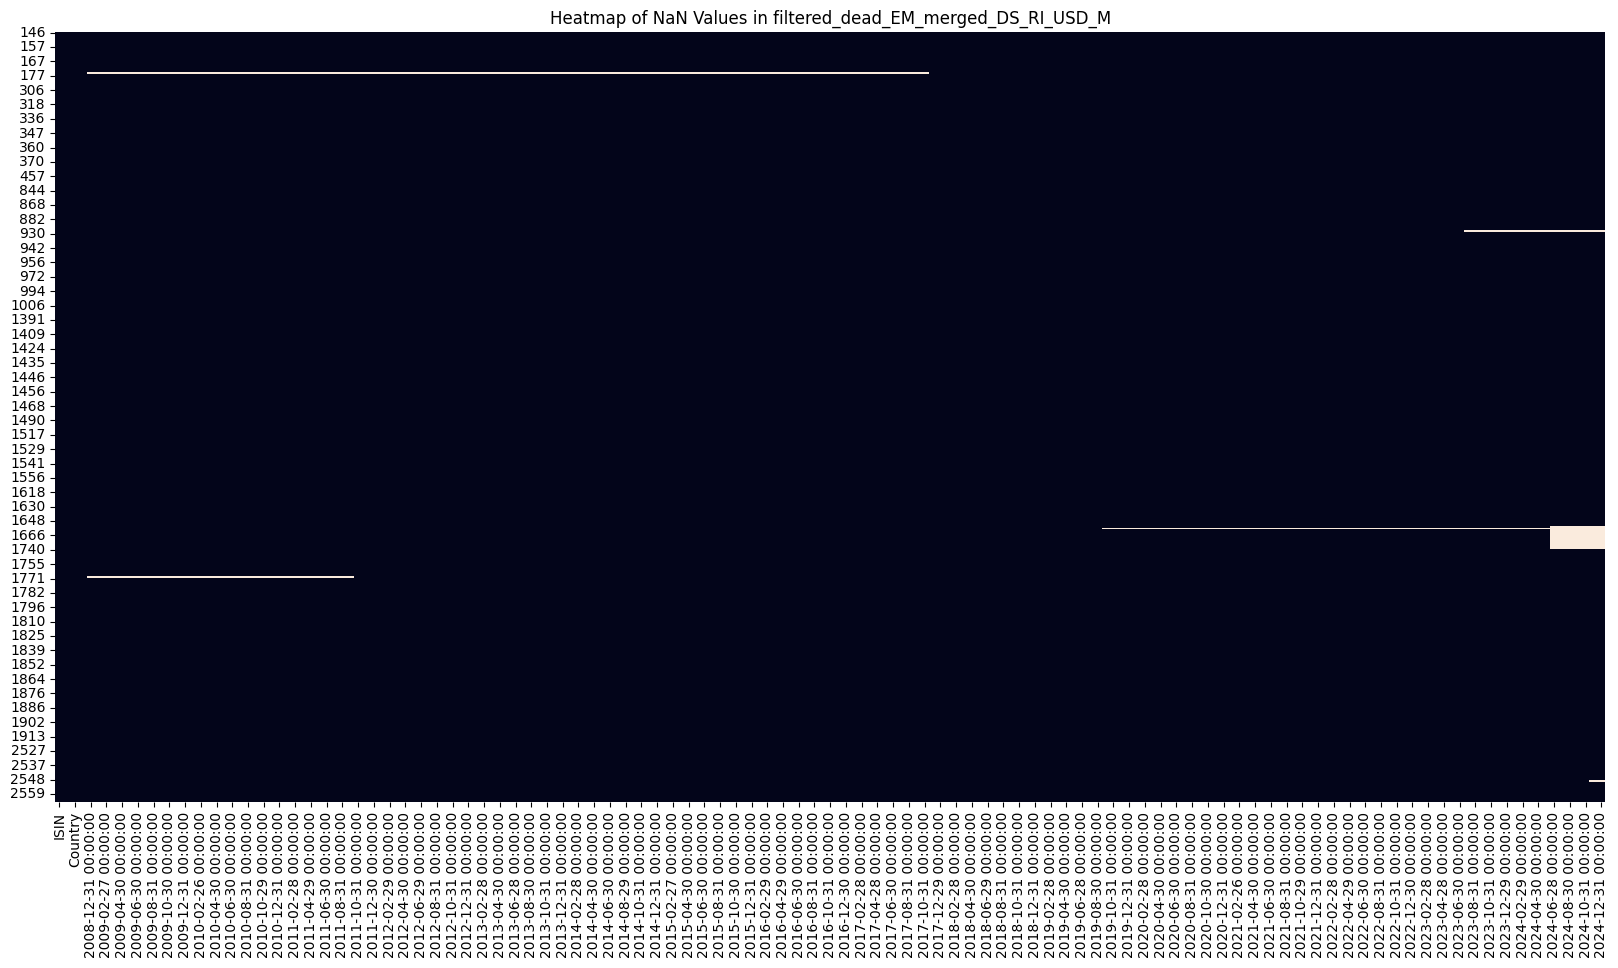

In [ ]:
plt.figure(figsize=(20, 10))  # Adjust figure size as needed
sns.heatmap(filtered_dead_EM_merged_DS_RI_USD_M.isnull(), cbar=False)
plt.title('Heatmap of NaN Values in filtered_dead_EM_merged_DS_RI_USD_M')
plt.show()

In [ ]:
df_nan_rows = filtered_dead_EM_merged_DS_RI_USD_M[filtered_dead_EM_merged_DS_RI_USD_M.isnull().any(axis=1)][['Name', 'ISIN']]
df_nan_rows

,Name,ISIN
175,SUZANO ON,BRSUZBACNOR0
928,HOUSING DEVELOPMENT FINANCE CORPORATION,INE001A01036
1660,MMC NORILSK NICKEL,RU0007288411
1661,URALKALI,RU0007661302
1662,GAZPROM,RU0007661625
1663,ROSTELECOM,RU0008943394
1664,NK LUKOIL,RU0009024277
1665,SBERBANK OF RUSSIA,RU0009029540
1666,TATNEFT,RU0009033591
1667,SEVERSTAL,RU0009046510


In [ ]:
isins_to_remove = df_nan_rows['ISIN'].tolist()

# Remove rows where ISIN is in isins_to_remove
filtered_dead_nan_EM_merged_DS_RI_USD_M = filtered_dead_EM_merged_DS_RI_USD_M[
    ~filtered_dead_EM_merged_DS_RI_USD_M['ISIN'].isin(isins_to_remove)
]

In [ ]:
nan_counts = filtered_dead_nan_EM_merged_DS_RI_USD_M.isnull().sum().sum()
print("Total number of NaN values:", nan_counts)

Total number of NaN values: 0


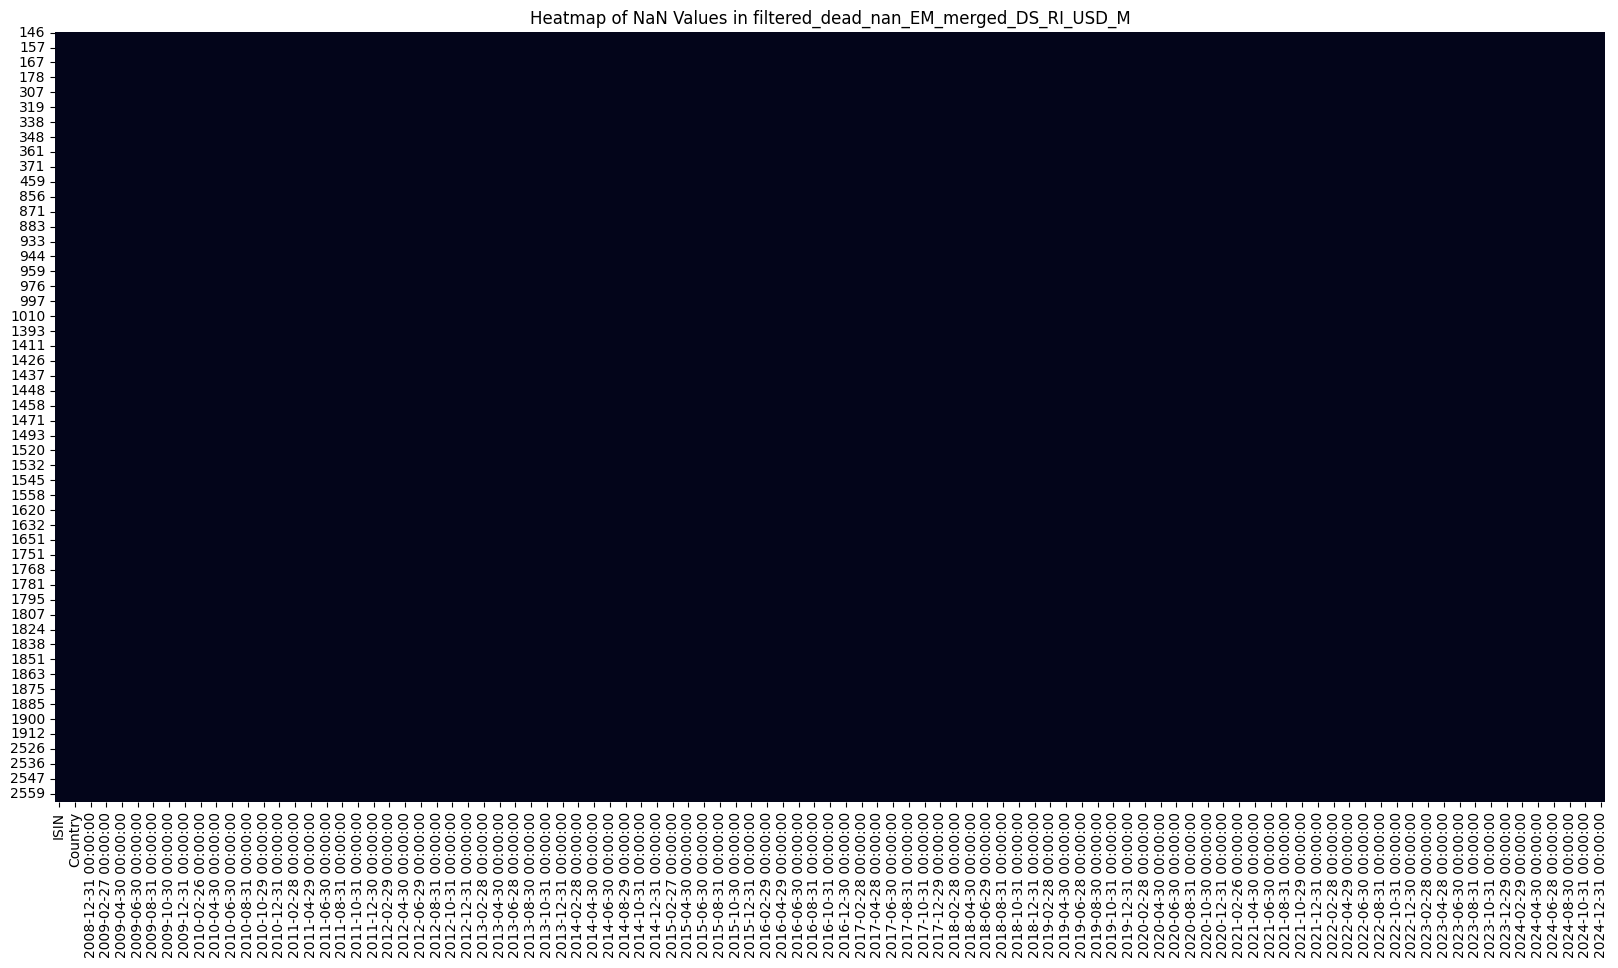

In [ ]:
plt.figure(figsize=(20, 10))  # Adjust figure size as needed
sns.heatmap(filtered_dead_nan_EM_merged_DS_RI_USD_M.isnull(), cbar=False)
plt.title('Heatmap of NaN Values in filtered_dead_nan_EM_merged_DS_RI_USD_M')
plt.show()

## Data frames

### Return index dataframe

In [ ]:
returns = filtered_dead_nan_EM_merged_DS_RI_USD_M

### Simple returns data frame

In [ ]:
# 1. Define metadata columns
metadata_cols = ['ISIN', 'Name', 'Country', 'Region']

# 2. Separate date and metadata columns
date_cols = [col for col in returns.columns if col not in metadata_cols]

# 3. Convert date columns to numeric (coerce errors)
data = returns[date_cols].apply(pd.to_numeric, errors='coerce')

# 4. Compute simple returns using built-in pct_change
returns_pct = data.pct_change(axis=1)

# 5. Replace infinite values and fill NaNs with 0
returns_pct.replace([np.inf, -np.inf], 0, inplace=True)
returns_pct.fillna(0, inplace=True)

# 6. Combine with metadata
simple_returns = pd.concat([
    returns[metadata_cols].reset_index(drop=True),
    returns_pct.reset_index(drop=True)
], axis=1)

simple_returns

,ISIN,Name,Country,Region,2008-12-31 00:00:00,2009-01-30 00:00:00,2009-02-27 00:00:00,2009-03-31 00:00:00,2009-04-30 00:00:00,2009-05-29 00:00:00,...,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00
0,BRABEVACNOR1,AMBEV ON,BR,EM,0.0,-0.042665,0.020508,0.139945,0.137388,0.202735,...,-0.014473,-0.060544,-0.061723,-0.066038,-0.002754,0.108466,0.057737,-0.090892,-0.023564,-0.060048
1,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,0.0,-0.029038,-0.024663,0.270417,0.161538,0.267537,...,-0.021737,-0.064611,-0.024629,-0.044654,-0.023276,0.075064,0.011822,-0.088666,-0.070730,-0.050255
2,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,0.0,-0.072389,-0.023411,0.155468,0.248645,0.234734,...,0.030787,-0.050563,-0.106172,-0.069301,-0.004353,0.265222,-0.015599,-0.072711,-0.140684,-0.108998
3,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,0.0,0.080043,-0.094964,0.001767,0.190736,0.338332,...,0.072827,-0.001119,0.085479,0.154542,-0.087171,0.243162,-0.062344,0.043383,-0.061078,-0.007831
4,BRBRKMACNPA4,BRASKEM PN A,BR,EM,0.0,0.032655,-0.078423,-0.077588,0.361663,0.277753,...,0.245496,-0.221552,-0.124134,-0.105816,-0.034452,0.026009,0.148867,-0.171098,-0.171820,-0.253886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,ZAE000191342,ALTRON LIMITED A,ZA,EM,0.0,-0.038896,-0.182688,0.103545,0.233599,0.102493,...,0.082942,0.040944,0.127626,0.080433,0.316925,0.012633,0.048533,0.034932,0.097795,0.007029
512,ZAE000255915,ABSA GROUP,ZA,EM,0.0,-0.220778,-0.027959,0.186990,0.148198,0.087830,...,-0.082512,0.036311,0.025936,0.095224,0.012335,0.127532,0.070606,-0.063144,0.001226,0.053002
513,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,0.0,-0.230407,0.267228,0.264653,0.235547,0.274169,...,0.052891,0.113964,0.037187,0.011843,0.124900,-0.242873,0.072477,0.164121,-0.154704,-0.170888
514,ZAE000302618,AVENG,ZA,EM,0.0,-0.221320,-0.009313,0.068622,0.408339,0.125422,...,-0.166667,0.000000,0.000000,0.200000,0.333333,0.125000,0.000000,-0.111111,0.250000,0.000000


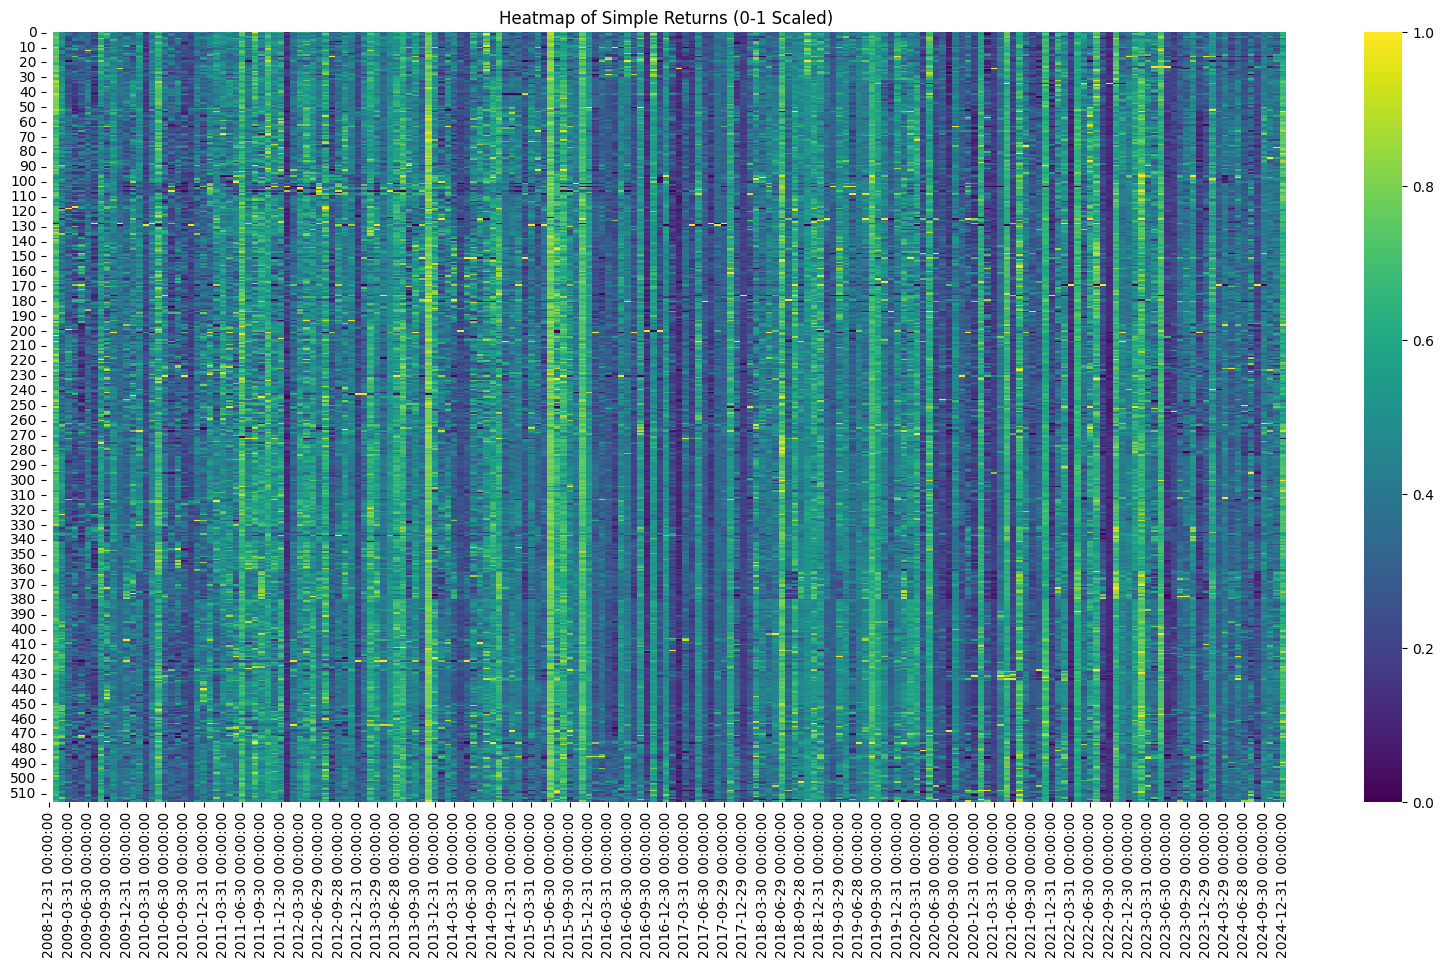

In [ ]:
# prompt: can you create a heat map of the values simple_returns, color coded from 0-1, not a correlation matrix

plt.figure(figsize=(20, 10))
sns.heatmap(simple_returns.iloc[:, 4:].apply(lambda x: (x - x.min()) / (x.max() - x.min())), cmap='viridis', annot=False)
plt.title('Heatmap of Simple Returns (0-1 Scaled)')
plt.show()


In [ ]:
# prompt: how many rows have more than 10 zeros

import pandas as pd

# Assuming your DataFrame is named 'simple_returns'
# ... (Your existing code to create the DataFrame) ...

row_zero_counts = (simple_returns.iloc[:, 4:] == 0).sum(axis=1)
rows_with_more_than_10_zeros = row_zero_counts[row_zero_counts > 10].count()

print("Number of rows with more than 10 zeros:", rows_with_more_than_10_zeros)


Number of rows with more than 10 zeros: 63


### E-Score data frame

In [ ]:
isin_list_R = simple_returns['ISIN'].tolist()

# Filter EM_merged_DS_EScore_Y to keep only rows with ISINs present in the list
EScore = EM_merged_DS_EScore_Y[EM_merged_DS_EScore_Y['ISIN'].isin(isin_list_R)].copy()

EScore

,ISIN,Name,Country,Region,2009-01-01 00:00:00,2010-01-01 00:00:00,2011-01-01 00:00:00,2012-01-01 00:00:00,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2017-01-01 00:00:00,2018-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00
145,BRABEVACNOR1,AMBEV ON,BR,EM,NaN,NaN,NaN,NaN,57.38,58.81,66.63,74.17,67.08,55.27,68.85,72.11,77.48,67.51,62.78
146,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,68.98,87.93,85.72,87.23,89.93,90.21,91.78,94.54,94.64,94.43,94.44,91.44,91.20,92.86,93.30
147,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,78.70,84.85,86.45,81.49,80.31,83.16,88.79,95.72,96.06,96.32,95.57,94.90,95.52,94.60,97.80
148,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,53.61,42.42,65.34,77.78,75.80,78.70,75.73,77.90,77.55,77.98,72.71,77.44,81.78,82.94,82.34
149,BRBRKMACNPA4,BRASKEM PN A,BR,EM,58.64,58.57,61.40,57.79,57.57,41.05,44.03,43.06,50.40,53.56,49.96,50.09,51.08,48.23,50.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2503,ZAE000191342,ALTRON LIMITED A,ZA,EM,NaN,NaN,NaN,43.78,44.42,54.31,56.78,59.55,57.53,30.93,30.08,27.51,38.62,31.87,37.06
2504,ZAE000255915,ABSA GROUP,ZA,EM,52.20,53.90,48.96,58.02,56.43,55.56,68.94,75.90,81.90,80.63,83.03,81.99,81.45,79.12,84.75
2505,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,NaN,60.96,53.53,59.07,54.34,54.03,52.42,56.64,53.90,63.37,62.03,67.79,73.50,74.37,63.96
2506,ZAE000302618,AVENG,ZA,EM,NaN,58.89,62.27,78.98,72.99,64.66,69.09,70.85,52.33,45.73,44.32,44.52,48.95,31.21,25.61


### Market cap data frame

In [ ]:
filtered_EM_DS_MV_USD_M = DS_MV_USD_M[DS_MV_USD_M['ISIN'].isin(isin_list_R)].copy()
market_cap_M = filtered_EM_DS_MV_USD_M

In [ ]:
filtered_EM_DS_MV_USD_Y = DS_MV_USD_Y[DS_MV_USD_Y['ISIN'].isin(isin_list_R)].copy()
market_cap_Y = filtered_EM_DS_MV_USD_Y

### Risk free rate data frame

In [ ]:
df = Risk_Free_Rate.copy()

df[df.columns[0]] = df[df.columns[0]].astype(str)

# Extract year (first 4 characters) and month (characters 5-6)
df['Year'] = df.iloc[:, 0].str[:4].astype(int)
df['Month'] = df.iloc[:, 0].str[4:6].astype(int)  # Extract month

# Get the last day of the month using calendar.monthrange
df['LastDay'] = df.apply(lambda row: calendar.monthrange(row['Year'], row['Month'])[1], axis=1)
# Rename 'LastDay' to 'Day' for pd.to_datetime
df = df.rename(columns={'LastDay': 'Day'}) # Rename to 'Day' to match expected input for pd.to_datetime

# Now create the 'ReadableDate' column using the calculated LastDay
df['date'] = pd.to_datetime(df[['Year', 'Month', 'Day']]) # Use 'Day' instead of 'LastDay'

# Drop the temporary 'Year', 'Month', and 'Day' columns
df = df.drop(['Year', 'Month', 'Day', 'Unnamed: 0' ], axis=1)

df = df[['date', 'RF']]

df['date'] = pd.to_datetime(df['date'])
df['RF'] = df['RF'] / 100

#df["RF"] = (1 + df["RF"]) ** (1/12) - 1
#df['RF'] = df['RF'] / 12

risk_free_rate = df

### Simple returns no zeros

In [ ]:
threshold = 0.85

def remove_rows_with_many_zeros(df, threshold):
  """Removes rows where the count of zero values exceeds the threshold."""
  rows_to_drop = []
  for index, row in df.iterrows():
    total_values = len(row)
    zero_count = (row == 0).sum()
    if total_values > 0 and (zero_count / total_values) > threshold:
      rows_to_drop.append(index)

  df_cleaned = df.drop(rows_to_drop)
  return df_cleaned

# Example usage:
simple_returns_cleaned = remove_rows_with_many_zeros(simple_returns, threshold)

# Print the cleaned DataFrame
simple_returns_no_zeros = simple_returns_cleaned

isin_list_simple_returns_cleaned = simple_returns_no_zeros['ISIN'].tolist()

In [ ]:
simple_returns_no_zeros

,ISIN,Name,Country,Region,2008-12-31 00:00:00,2009-01-30 00:00:00,2009-02-27 00:00:00,2009-03-31 00:00:00,2009-04-30 00:00:00,2009-05-29 00:00:00,...,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00
0,BRABEVACNOR1,AMBEV ON,BR,EM,0.0,-0.042665,0.020508,0.139945,0.137388,0.202735,...,-0.014473,-0.060544,-0.061723,-0.066038,-0.002754,0.108466,0.057737,-0.090892,-0.023564,-0.060048
1,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,0.0,-0.029038,-0.024663,0.270417,0.161538,0.267537,...,-0.021737,-0.064611,-0.024629,-0.044654,-0.023276,0.075064,0.011822,-0.088666,-0.070730,-0.050255
2,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,0.0,-0.072389,-0.023411,0.155468,0.248645,0.234734,...,0.030787,-0.050563,-0.106172,-0.069301,-0.004353,0.265222,-0.015599,-0.072711,-0.140684,-0.108998
3,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,0.0,0.080043,-0.094964,0.001767,0.190736,0.338332,...,0.072827,-0.001119,0.085479,0.154542,-0.087171,0.243162,-0.062344,0.043383,-0.061078,-0.007831
4,BRBRKMACNPA4,BRASKEM PN A,BR,EM,0.0,0.032655,-0.078423,-0.077588,0.361663,0.277753,...,0.245496,-0.221552,-0.124134,-0.105816,-0.034452,0.026009,0.148867,-0.171098,-0.171820,-0.253886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,ZAE000191342,ALTRON LIMITED A,ZA,EM,0.0,-0.038896,-0.182688,0.103545,0.233599,0.102493,...,0.082942,0.040944,0.127626,0.080433,0.316925,0.012633,0.048533,0.034932,0.097795,0.007029
512,ZAE000255915,ABSA GROUP,ZA,EM,0.0,-0.220778,-0.027959,0.186990,0.148198,0.087830,...,-0.082512,0.036311,0.025936,0.095224,0.012335,0.127532,0.070606,-0.063144,0.001226,0.053002
513,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,0.0,-0.230407,0.267228,0.264653,0.235547,0.274169,...,0.052891,0.113964,0.037187,0.011843,0.124900,-0.242873,0.072477,0.164121,-0.154704,-0.170888
514,ZAE000302618,AVENG,ZA,EM,0.0,-0.221320,-0.009313,0.068622,0.408339,0.125422,...,-0.166667,0.000000,0.000000,0.200000,0.333333,0.125000,0.000000,-0.111111,0.250000,0.000000


In [ ]:
nan_count = simple_returns_no_zeros.isnull().sum().sum()
print(f"Total number of NaN values in simple_returns_no_zeros: {nan_count}")

Total number of NaN values in simple_returns_no_zeros: 0


<ipython-input-32-5f35010a523e>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  sns.heatmap(simple_returns_no_zeros.iloc[:, 4:].applymap(lambda x: 1 if x == 0 else 0), cbar=False)


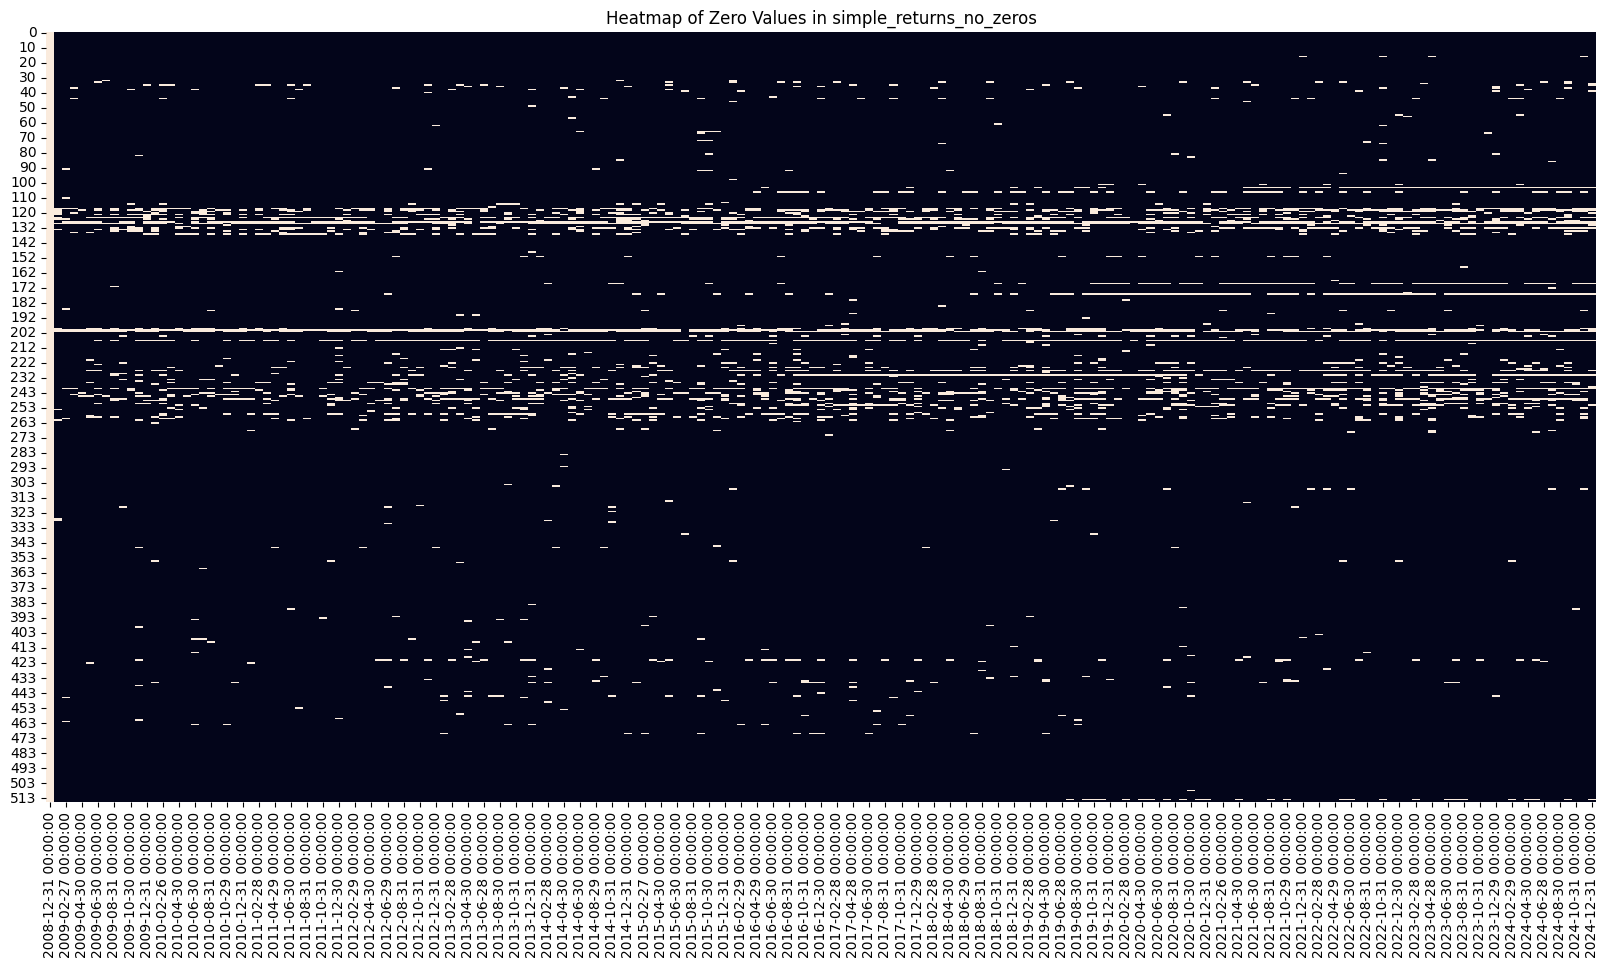

In [ ]:
plt.figure(figsize=(20, 10))
sns.heatmap(simple_returns_no_zeros.iloc[:, 4:].applymap(lambda x: 1 if x == 0 else 0), cbar=False)
plt.title('Heatmap of Zero Values in simple_returns_no_zeros')
plt.show()

### E-Score no zeros

In [ ]:
EScore_no_zeros = EM_merged_DS_EScore_Y[EM_merged_DS_EScore_Y['ISIN'].isin(isin_list_simple_returns_cleaned)].copy()
EScore_no_zeros

,ISIN,Name,Country,Region,2009-01-01 00:00:00,2010-01-01 00:00:00,2011-01-01 00:00:00,2012-01-01 00:00:00,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2017-01-01 00:00:00,2018-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00
145,BRABEVACNOR1,AMBEV ON,BR,EM,NaN,NaN,NaN,NaN,57.38,58.81,66.63,74.17,67.08,55.27,68.85,72.11,77.48,67.51,62.78
146,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,68.98,87.93,85.72,87.23,89.93,90.21,91.78,94.54,94.64,94.43,94.44,91.44,91.20,92.86,93.30
147,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,78.70,84.85,86.45,81.49,80.31,83.16,88.79,95.72,96.06,96.32,95.57,94.90,95.52,94.60,97.80
148,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,53.61,42.42,65.34,77.78,75.80,78.70,75.73,77.90,77.55,77.98,72.71,77.44,81.78,82.94,82.34
149,BRBRKMACNPA4,BRASKEM PN A,BR,EM,58.64,58.57,61.40,57.79,57.57,41.05,44.03,43.06,50.40,53.56,49.96,50.09,51.08,48.23,50.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2503,ZAE000191342,ALTRON LIMITED A,ZA,EM,NaN,NaN,NaN,43.78,44.42,54.31,56.78,59.55,57.53,30.93,30.08,27.51,38.62,31.87,37.06
2504,ZAE000255915,ABSA GROUP,ZA,EM,52.20,53.90,48.96,58.02,56.43,55.56,68.94,75.90,81.90,80.63,83.03,81.99,81.45,79.12,84.75
2505,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,NaN,60.96,53.53,59.07,54.34,54.03,52.42,56.64,53.90,63.37,62.03,67.79,73.50,74.37,63.96
2506,ZAE000302618,AVENG,ZA,EM,NaN,58.89,62.27,78.98,72.99,64.66,69.09,70.85,52.33,45.73,44.32,44.52,48.95,31.21,25.61


### Market Cap no zeros

In [ ]:
market_cap_M_no_zeros = DS_MV_USD_M[DS_MV_USD_M['ISIN'].isin(isin_list_simple_returns_cleaned)].copy()
market_cap_M_no_zeros

,NAME,ISIN,1999-12-31 00:00:00,2000-01-31 00:00:00,2000-02-29 00:00:00,2000-03-31 00:00:00,2000-04-28 00:00:00,2000-05-31 00:00:00,2000-06-30 00:00:00,2000-07-31 00:00:00,...,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00,2025-01-31 00:00:00
146,AMBEV ON,BRABEVACNOR1,898.33,848.69,810.12,1064.46,1062.92,1017.51,1287.05,1591.09,...,36938.22,34658.22,32369.65,32280.60,35781.82,37847.65,34407.58,33596.80,29944.81,29942.67
147,BANCO DO BRASIL ON,BRBBASACNOR3,1869.6,1744.22,1680.67,1438.89,1327.29,1246.41,1427.23,1404.38,...,30317.50,29570.88,27558.30,26916.82,28455.29,28602.67,26066.58,23775.07,22421.07,27155.61
148,BANCO BRADESCO PN,BRBBDCACNPR8,4233.93,4330.41,3849.25,4416.12,3920.07,3616.62,4663.78,4660.55,...,14347.73,12805.03,11839.36,11680.45,14669.45,14338.50,13186.18,11236.44,9939.55,10993.84
149,BRF BRASIL FOODS ON,BRBRFSACNOR8,168.22,126.22,126.78,128.56,124.32,126.71,127.79,113.22,...,5479.35,5947.72,6866.89,6268.28,7792.49,7306.66,7623.63,6991.22,6906.52,6304.78
150,BRASKEM PN A,BRBRKMACNPA4,378.1,382.60,389.65,390.56,382.71,373.34,422.45,509.39,...,1416.69,1240.83,1109.52,1071.31,1099.16,1262.82,1046.73,866.89,646.79,815.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,ALTRON LIMITED A,ZAE000191342,105.41,115.91,106.13,113.98,90.17,76.58,74.37,85.52,...,248.89,280.70,295.36,388.98,393.90,413.00,427.45,460.04,463.34,472.18
2561,ABSA GROUP,ZAE000255915,2882.25,2649.35,2483.04,2348.10,2295.91,2374.43,2458.35,2347.50,...,6906.91,7086.12,7760.90,7856.60,8858.64,9105.44,8530.48,8540.85,8993.55,8893.95
2562,NORTHAM PLATINUM HLDGS,ZAE000298253,230.57,259.71,207.52,249.66,193.50,206.19,264.77,300.82,...,2632.31,2730.05,2762.38,3107.39,2352.88,2507.23,2918.45,2467.31,2045.45,2687.92
2563,AVENG,ZAE000302618,436.66,445.83,454.09,389.04,351.95,276.11,312.53,299.24,...,42.32,39.84,48.32,61.15,71.10,70.09,66.52,78.76,84.89,83.96


In [ ]:
market_cap_Y_no_zeros = DS_MV_USD_Y[DS_MV_USD_Y['ISIN'].isin(isin_list_simple_returns_cleaned)].copy()
market_cap_Y_no_zeros

,NAME,ISIN,1999,2000,2001,2002,2003,2004,2005,2006,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
146,AMBEV ON,BRABEVACNOR1,NaN,819.89,3937.94,2602.40,1896.76,3559.93,11591.19,12592.77,...,99515.76,69538.70,90471.62,107508.68,77276.64,56712.12,39584.64,46420.10,40387.05,41249.56
147,BANCO DO BRASIL ON,BRBBASACNOR3,1229.28,1699.83,1491.64,1777.86,1936.54,5436.48,9889.44,20860.01,...,22818.99,9491.81,30601.78,38066.35,39989.52,29529.50,14422.12,19569.90,22329.53,33330.86
148,BANCO BRADESCO PN,BRBBDCACNPR8,1985.4,4140.79,4189.36,4149.60,2015.24,3825.63,7645.06,20084.50,...,27716.97,13100.56,29942.02,38172.77,40138.61,27651.57,18303.76,19138.44,13621.42,14719.11
149,BRF BRASIL FOODS ON,BRBRFSACNOR8,48.47,126.53,114.56,96.60,69.13,147.38,293.92,579.23,...,20231.08,10194.51,10648.29,7175.60,4725.59,5266.64,3154.82,3508.56,1346.17,4733.06
150,BRASKEM PN A,BRBRKMACNPA4,90.45,386.95,352.75,243.08,98.96,1220.00,3031.10,2055.91,...,1588.06,2159.27,3598.81,5028.61,5139.27,2269.71,1935.44,3194.64,1319.91,1446.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,ALTRON LIMITED A,ZAE000191342,94.56,107.67,99.15,64.30,100.20,168.36,266.46,404.40,...,164.32,29.98,81.55,438.82,534.90,527.84,305.93,201.56,186.80,206.59
2561,ABSA GROUP,ZAE000255915,2769.41,2538.47,2643.38,1648.06,2716.00,4536.54,8868.79,12924.62,...,14339.19,7622.05,10219.45,14896.64,11171.05,8074.78,6791.52,9884.60,9004.67,7674.69
2562,NORTHAM PLATINUM HLDGS,ZAE000298253,129.22,211.66,457.28,312.74,451.25,376.75,351.63,1032.35,...,1727.00,1049.09,1987.98,1878.19,2067.38,4399.06,7468.55,5917.59,3332.08,2267.72
2563,AVENG,ZAE000302618,NaN,460.16,397.60,257.32,465.76,462.54,801.12,1509.59,...,562.52,77.34,231.85,61.56,41.90,25.62,78.03,164.93,106.15,47.52


# Data frames restricted time frame

### Simple returns no zeros

In [ ]:
df = simple_returns_no_zeros.copy()

# Ensure the ISIN column is included and set as the index
df.set_index("ISIN", inplace=True)

# Convert date columns to datetime format
df.columns = list(df.columns[:3]) + list(pd.to_datetime(df.columns[3:]))

start_date = pd.to_datetime('2009-01-30 00:00:00')
end_date = pd.to_datetime('2024-12-31 00:00:00')

# Select only the date range columns
simple_returns_M_2009_2024 = df.loc[:, start_date:end_date]

simple_returns_M_2009_2024

,2009-01-30,2009-02-27,2009-03-31,2009-04-30,2009-05-29,2009-06-30,2009-07-31,2009-08-31,2009-09-30,2009-10-30,...,2024-03-29,2024-04-30,2024-05-31,2024-06-28,2024-07-31,2024-08-30,2024-09-30,2024-10-31,2024-11-29,2024-12-31
ISIN,,,,,,,,,,,,,,,,,,,,,
BRABEVACNOR1,-0.042665,0.020508,0.139945,0.137388,0.202735,-0.015351,0.071526,0.127902,0.112810,0.082226,...,-0.014473,-0.060544,-0.061723,-0.066038,-0.002754,0.108466,0.057737,-0.090892,-0.023564,-0.060048
BRBBASACNOR3,-0.029038,-0.024663,0.270417,0.161538,0.267537,0.015014,0.165587,0.118995,0.260807,-0.077842,...,-0.021737,-0.064611,-0.024629,-0.044654,-0.023276,0.075064,0.011822,-0.088666,-0.070730,-0.050255
BRBBDCACNPR8,-0.072389,-0.023411,0.155468,0.248645,0.234734,-0.036107,0.067797,0.046571,0.205743,0.002816,...,0.030787,-0.050563,-0.106172,-0.069301,-0.004353,0.265222,-0.015599,-0.072711,-0.140684,-0.108998
BRBRFSACNOR8,0.080043,-0.094964,0.001767,0.190736,0.338332,-0.038486,0.152918,0.018109,0.179561,-0.076438,...,0.072827,-0.001119,0.085479,0.154542,-0.087171,0.243162,-0.062344,0.043383,-0.061078,-0.007831
BRBRKMACNPA4,0.032655,-0.078423,-0.077588,0.361663,0.277753,0.007898,0.208685,0.263173,0.129916,0.060759,...,0.245496,-0.221552,-0.124134,-0.105816,-0.034452,0.026009,0.148867,-0.171098,-0.171820,-0.253886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZAE000191342,-0.038896,-0.182688,0.103545,0.233599,0.102493,0.190152,0.065484,0.002709,0.024090,0.047046,...,0.082942,0.040944,0.127626,0.080433,0.316925,0.012633,0.048533,0.034932,0.097795,0.007029
ZAE000255915,-0.220778,-0.027959,0.186990,0.148198,0.087830,0.127362,0.052348,0.105134,-0.026847,0.004522,...,-0.082512,0.036311,0.025936,0.095224,0.012335,0.127532,0.070606,-0.063144,0.001226,0.053002
ZAE000298253,-0.230407,0.267228,0.264653,0.235547,0.274169,-0.087102,0.218085,0.087063,-0.144615,0.088641,...,0.052891,0.113964,0.037187,0.011843,0.124900,-0.242873,0.072477,0.164121,-0.154704,-0.170888


### Market cap no zeros

In [ ]:
df = market_cap_Y_no_zeros.copy()

# Ensure the ISIN column is included and set as the index
df.set_index("ISIN", inplace=True)

# Convert date columns to datetime format
df.columns = list(df.columns[:2]) + list(pd.to_datetime(df.columns[2:]))

start_date = pd.to_datetime('2009')
end_date = pd.to_datetime('2024')

# Select only the date range columns
market_cap_Y_2009_2024 = df.loc[:, start_date:end_date]

market_cap_Y_2009_2024

,2009-01-01 00:00:00,2010-01-01 00:00:00,2011-01-01 00:00:00,2012-01-01 00:00:00,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2017-01-01 00:00:00,2018-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00,2024-01-01 00:00:00
ISIN,,,,,,,,,,,,,,,,
BRABEVACNOR1,12459.26,28572.71,38352.47,58002.65,77661.18,112045.24,99515.76,69538.70,90471.62,107508.68,77276.64,56712.12,39584.64,46420.10,40387.05,41249.56
BRBBASACNOR3,15311.83,42291.45,50279.94,45935.40,36647.03,23818.34,22818.99,9491.81,30601.78,38066.35,39989.52,29529.50,14422.12,19569.90,22329.53,33330.86
BRBBDCACNPR8,13831.15,29506.49,36054.97,34042.85,33523.21,23987.44,27716.97,13100.56,29942.02,38172.77,40138.61,27651.57,18303.76,19138.44,13621.42,14719.11
BRBRFSACNOR8,2592.31,10634.70,15061.16,17852.74,18677.98,14895.12,20231.08,10194.51,10648.29,7175.60,4725.59,5266.64,3154.82,3508.56,1346.17,4733.06
BRBRKMACNPA4,734.86,2330.45,4210.54,3182.58,2547.68,2433.94,1588.06,2159.27,3598.81,5028.61,5139.27,2269.71,1935.44,3194.64,1319.91,1446.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZAE000191342,212.03,358.46,391.78,331.51,260.48,236.45,164.32,29.98,81.55,438.82,534.90,527.84,305.93,201.56,186.80,206.59
ZAE000255915,6498.75,12444.13,13278.42,15056.44,13286.88,10409.74,14339.19,7622.05,10219.45,14896.64,11171.05,8074.78,6791.52,9884.60,9004.67,7674.69
ZAE000298253,833.24,2094.32,2543.85,1687.29,1695.81,1502.48,1727.00,1049.09,1987.98,1878.19,2067.38,4399.06,7468.55,5917.59,3332.08,2267.72


### E-Score no zeros

In [ ]:
df = EScore_no_zeros.copy()

# Ensure the ISIN column is included and set as the index
df.set_index("ISIN", inplace=True)

# Convert date columns to datetime format
df.columns = list(df.columns[:4]) + list(pd.to_datetime(df.columns[4:]))

start_date = pd.to_datetime('2009')
end_date = pd.to_datetime('2023')

# Select only the date range columns
EScore_Y_2009_2024 = df.loc[:, start_date:end_date]

EScore_Y_2009_2024

,2009-01-01 00:00:00,2010-01-01 00:00:00,2011-01-01 00:00:00,2012-01-01 00:00:00,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2017-01-01 00:00:00,2018-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00
ISIN,,,,,,,,,,,,,,,
BRABEVACNOR1,NaN,NaN,NaN,NaN,57.38,58.81,66.63,74.17,67.08,55.27,68.85,72.11,77.48,67.51,62.78
BRBBASACNOR3,68.98,87.93,85.72,87.23,89.93,90.21,91.78,94.54,94.64,94.43,94.44,91.44,91.20,92.86,93.30
BRBBDCACNPR8,78.70,84.85,86.45,81.49,80.31,83.16,88.79,95.72,96.06,96.32,95.57,94.90,95.52,94.60,97.80
BRBRFSACNOR8,53.61,42.42,65.34,77.78,75.80,78.70,75.73,77.90,77.55,77.98,72.71,77.44,81.78,82.94,82.34
BRBRKMACNPA4,58.64,58.57,61.40,57.79,57.57,41.05,44.03,43.06,50.40,53.56,49.96,50.09,51.08,48.23,50.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZAE000191342,NaN,NaN,NaN,43.78,44.42,54.31,56.78,59.55,57.53,30.93,30.08,27.51,38.62,31.87,37.06
ZAE000255915,52.20,53.90,48.96,58.02,56.43,55.56,68.94,75.90,81.90,80.63,83.03,81.99,81.45,79.12,84.75
ZAE000298253,NaN,60.96,53.53,59.07,54.34,54.03,52.42,56.64,53.90,63.37,62.03,67.79,73.50,74.37,63.96


# Question 4: Daniel

### Value-Weighted Tracking Error

In [ ]:
# === Replace with your actual DataFrames ===
market_cap_df = market_cap_Y_2009_2024
EScore_df = EScore_Y_2009_2024
returns_df = simple_returns_M_2009_2024

market_cap_df.columns = pd.to_datetime(market_cap_df.columns).year.astype(str)
EScore_df.columns = pd.to_datetime(EScore_df.columns).year.astype(str)

returns_df.columns = pd.to_datetime(returns_df.columns)

# === Store results ===
optimized_weights_by_year = {}
benchmark_scores = {}
optimized_scores = {}

# === Loop through years ===
for year in range(2013, 2024):
    print(f"Processing year: {year}")

    try:
        # --- Extract benchmark inputs ---
        market_caps = market_cap_df[str(year)]
        ESG_scores = EScore_df[str(year)]

        # Drop missing firms
        valid_firms = market_caps.dropna().index.intersection(ESG_scores.dropna().index)
        market_caps = market_caps.loc[valid_firms]
        ESG_scores = ESG_scores.loc[valid_firms]

        alpha_vw = market_caps / market_caps.sum()  # benchmark weights
        Sc_vw = np.dot(alpha_vw, ESG_scores)        # benchmark ESG score

        # --- Covariance matrix  ---

        #mask = returns_df.columns.to_series().dt.year == year + 0
        mask = returns_df.columns.to_series().dt.year.isin([year -4, year -3, year -2, year-1, year])
        returns_year = returns_df.loc[valid_firms, mask]

        Sigma = returns_year.T.cov().values  # Covariance matrix

        n_assets = len(alpha_vw)

        # --- Optimization setup ---
        def tracking_error_variance(alpha, alpha_vw, Sigma):
            diff = alpha - alpha_vw
            return diff.T @ Sigma @ diff

        constraint_sum = {'type': 'eq', 'fun': lambda alpha: np.sum(alpha) - 1}
        constraint_esg = {
            'type': 'ineq',
            'fun': lambda alpha: np.dot(alpha, ESG_scores.values) - 1.2 * Sc_vw
        }
        bounds = [(0, 1) for _ in range(n_assets)]
        constraints = [constraint_sum, constraint_esg]

        x0 = alpha_vw.values

        # --- Run optimizer ---
        result = minimize(
            tracking_error_variance,
            x0=x0,
            args=(alpha_vw.values, Sigma),
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )

        if result.success:
            optimized_weights = pd.Series(result.x, index=valid_firms)
            optimized_weights_by_year[year] = optimized_weights

            # Store ESG scores
            benchmark_scores[year] = Sc_vw
            optimized_scores[year] = np.dot(result.x, ESG_scores.values)

        else:
            print(f"Optimization failed for year {year}: {result.message}")

    except Exception as e:
        print(f"Error in year {year}: {e}")

Processing year: 2013
Processing year: 2014
Processing year: 2015
Processing year: 2016
Processing year: 2017
Processing year: 2018
Processing year: 2019
Processing year: 2020
Processing year: 2021
Processing year: 2022
Processing year: 2023


In [ ]:
# Combine optimized weights into one DataFrame
optimized_weights_df = pd.DataFrame(optimized_weights_by_year)

# ESG scores comparison
score_comparison = pd.DataFrame({
    'benchmark_ESG': benchmark_scores,
    'optimized_ESG': optimized_scores
})

In [ ]:
score_comparison

,benchmark_ESG,optimized_ESG
2013,55.473684,66.568420
2014,56.301051,67.561261
2015,59.805356,71.766427
2016,62.879963,75.455956
2017,66.558879,79.870655
2018,68.462681,82.155218
2019,69.115006,82.938007
2020,69.111034,82.933240
2021,70.273257,84.327909
2022,72.681526,87.217831


In [ ]:
optimized_annual_returns = {}
benchmark_annual_returns = {}
optimized_annual_returns_comp = {}
benchmark_annual_returns_comp = {}

for year, weights_opt in optimized_weights_by_year.items():
    firms = weights_opt.index

    # Get market-cap weights for benchmark
    market_caps = market_cap_df[str(year)].loc[firms]
    weights_benchmark = market_caps / market_caps.sum()

    # Returns for the NEXT year
    next_year = year + 1
    next_year_mask = returns_df.columns.to_series().dt.year == next_year
    returns_next_year = returns_df.loc[firms, next_year_mask]

    if returns_next_year.empty:
        continue

    # === Matrix multiplication: weights.T @ monthly returns ===
    monthly_returns_opt = weights_opt @ returns_next_year
    monthly_returns_benchmark = weights_benchmark @ returns_next_year

    # === Total annual return (additive or compounded) ===



    # Additive version:
    optimized_annual_returns[next_year] = monthly_returns_opt.mean()*12
    benchmark_annual_returns[next_year] = monthly_returns_benchmark.mean()*12

    optimized_annual_returns

    # # Or Compounded version (optional)
    optimized_annual_returns_comp[next_year] = (monthly_returns_opt + 1).prod() - 1
    benchmark_annual_returns_comp[next_year] = (monthly_returns_benchmark + 1).prod() - 1

In [ ]:
import numpy as np

# Convert dict values to a list or array
opt_returns = np.array(list(optimized_annual_returns_comp.values()))
bench_returns = np.array(list(benchmark_annual_returns_comp.values()))

# Compound returns across the years
optimized_total_return = np.prod(opt_returns + 1) - 1
benchmark_total_return = np.prod(bench_returns + 1) - 1

print("Total compounded return (optimized):", optimized_total_return)
print("Total compounded return (benchmark):", benchmark_total_return)

Total compounded return (optimized): 1.3180142708165685
Total compounded return (benchmark): 1.0609955303560992


In [ ]:
opt_returns

array([ 0.056171  , -0.16223388,  0.18299446,  0.35491843, -0.06943732,
        0.14081187,  0.1210559 ,  0.14061466, -0.04682938,  0.20852001,
        0.04523236])

In [ ]:
bench_returns

array([ 0.05787491, -0.16815002,  0.15461546,  0.33774016, -0.08438662,
        0.15334022,  0.09627974,  0.11287828, -0.078101  ,  0.20640677,
        0.05821243])

In [ ]:
optimized_monthly_returns = {}
benchmark_monthly_returns = {}

for year, weights_opt in optimized_weights_by_year.items():
    firms = weights_opt.index

    market_caps = market_cap_df[str(year)].loc[firms]
    weights_benchmark = market_caps / market_caps.sum()

    next_year = year + 1
    next_year_mask = returns_df.columns.to_series().dt.year == next_year
    returns_next_year = returns_df.loc[firms, next_year_mask]

    if returns_next_year.empty:
        continue

    monthly_returns_opt = weights_opt @ returns_next_year
    monthly_returns_benchmark = weights_benchmark @ returns_next_year

    # Store monthly returns instead of annual
    optimized_monthly_returns[next_year] = monthly_returns_opt
    benchmark_monthly_returns[next_year] = monthly_returns_benchmark


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Combine all monthly returns into one time series
opt_returns_series = pd.concat(optimized_monthly_returns.values())
bench_returns_series = pd.concat(benchmark_monthly_returns.values())

# Align the index (make sure it uses datetime if it's not already)
opt_returns_series.index = pd.to_datetime(opt_returns_series.index)
bench_returns_series.index = pd.to_datetime(bench_returns_series.index)


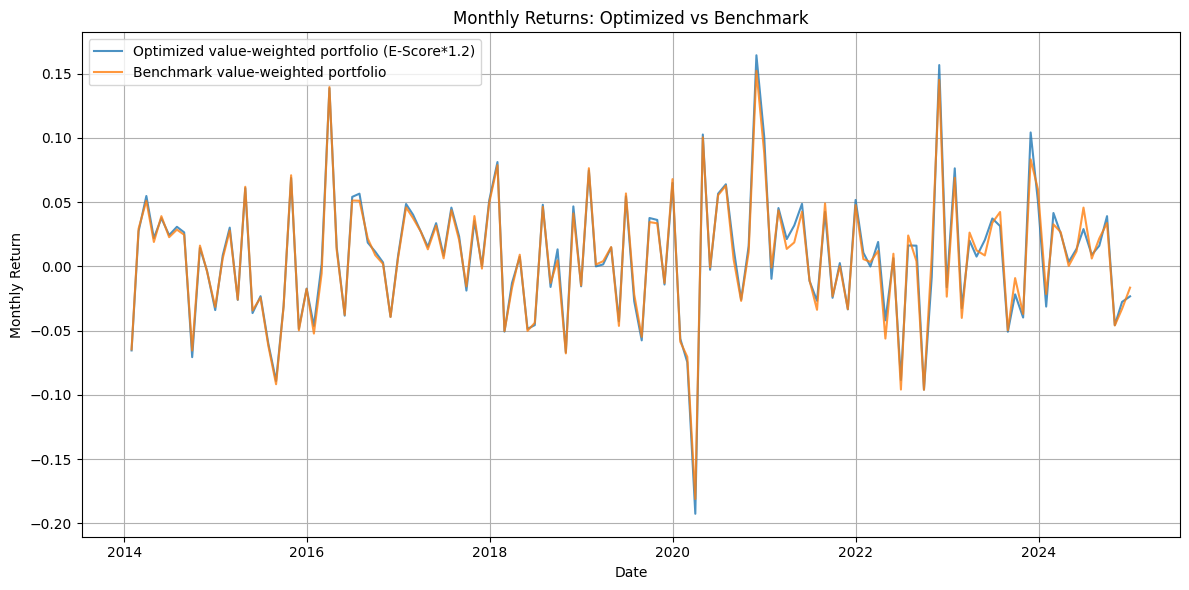

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(opt_returns_series, label='Optimized value-weighted portfolio (E-Score*1.2)', alpha=0.8)
plt.plot(bench_returns_series, label='Benchmark value-weighted portfolio', alpha=0.8)
plt.title('Monthly Returns: Optimized vs Benchmark')
plt.xlabel('Date')
plt.ylabel('Monthly Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
opt_returns_series

,0
2014-01-31,-0.065454
2014-02-28,0.027331
2014-03-31,0.054782
2014-04-30,0.021996
2014-05-30,0.037501
...,...
2024-08-30,0.016040
2024-09-30,0.039071
2024-10-31,-0.045811
2024-11-29,-0.027682


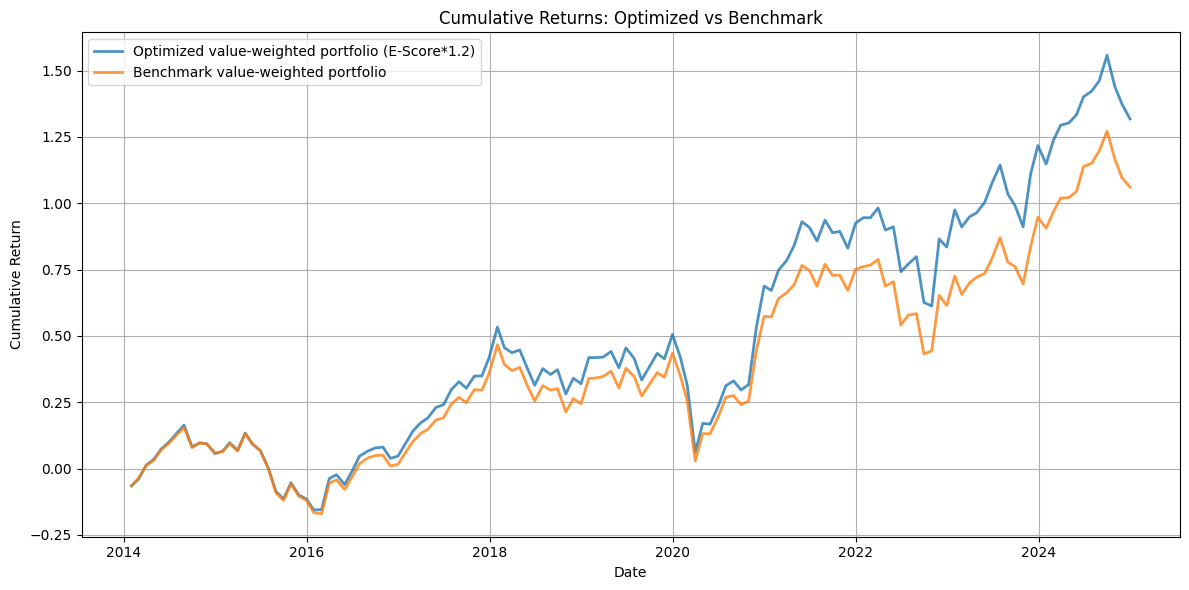

In [ ]:
cumulative_opt = (1 + opt_returns_series).cumprod() -1
cumulative_bench = (1 + bench_returns_series).cumprod() -1

plt.figure(figsize=(12, 6))
plt.plot(cumulative_opt, label='Optimized value-weighted portfolio (E-Score*1.2)', alpha=0.8, linewidth =2)
plt.plot(cumulative_bench, label='Benchmark value-weighted portfolio', alpha=0.8, linewidth =2)
plt.title('Cumulative Returns: Optimized vs Benchmark')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


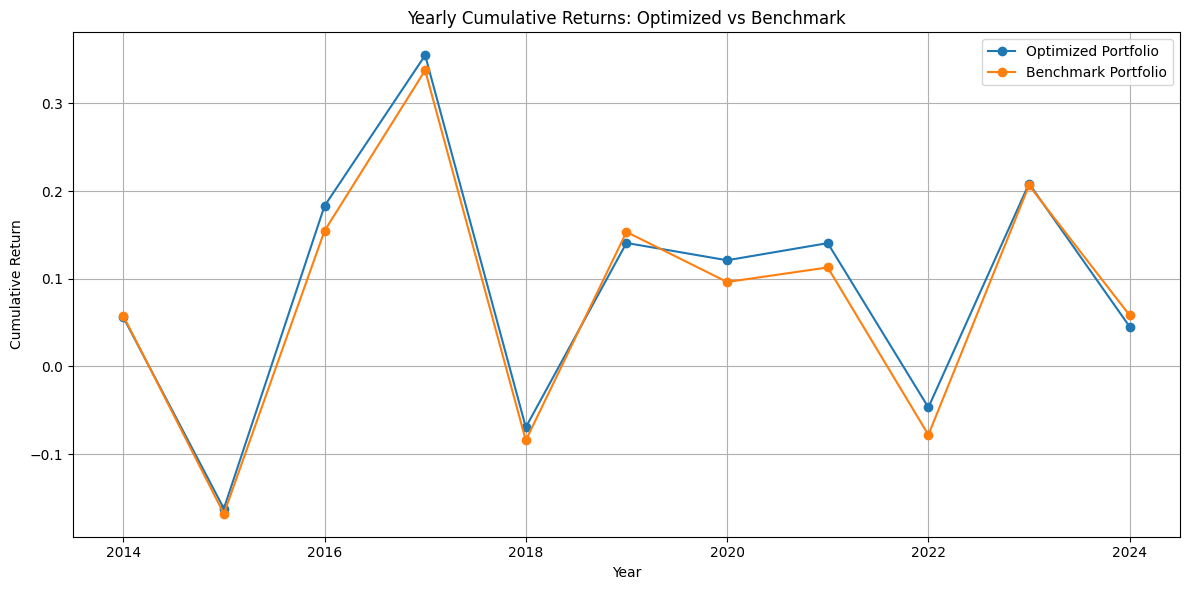

In [ ]:
# Convert to yearly cumulative returns
yearly_opt = (1 + opt_returns_series).groupby(opt_returns_series.index.year).prod() - 1
yearly_bench = (1 + bench_returns_series).groupby(bench_returns_series.index.year).prod() - 1

# Plot
plt.figure(figsize=(12, 6))
plt.plot(yearly_opt, label='Optimized Portfolio', marker='o')
plt.plot(yearly_bench, label='Benchmark Portfolio', marker='o')
plt.title('Yearly Cumulative Returns: Optimized vs Benchmark')
plt.xlabel('Year')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# prompt: can you find the companies with contribute the most to this weights_opt, and find their names via the ISIN in the df returns

# Assuming optimized_weights_by_year is a dictionary with year as keys and pd.Series as values
# where the series contains the weights of each company in that year, indexed by ISIN.
# We also assume returns has an ISIN column with the company ISIN.

# Example: Get the most important company in 2023
year_to_check = 2023
if year_to_check in optimized_weights_by_year:
  weights_opt = optimized_weights_by_year[year_to_check]
  most_important_isin = weights_opt.idxmax()

  # Find company name using the ISIN
  company_name = returns[returns['ISIN'] == most_important_isin]['Name'].values

  if len(company_name) > 0:
    print(f"In {year_to_check}, the company with the highest contribution to the portfolio is: {company_name[0]} (ISIN: {most_important_isin})")
  else:
    print(f"ISIN {most_important_isin} not found in the returns dataframe")
else:
  print(f"No optimized weights found for the year {year_to_check}.")


# To find the top N companies with the highest contributions, you can use nlargest()
def find_top_n_companies(year, n=5):
  if year in optimized_weights_by_year:
    weights_opt = optimized_weights_by_year[year]
    top_n_isins = weights_opt.nlargest(n).index.tolist()

    for isin in top_n_isins:
      company_name = returns[returns['ISIN'] == isin]['Name'].values
      if len(company_name) > 0:
        print(f"In {year}, {company_name[0]} (ISIN: {isin}) has a weight of {weights_opt[isin]}")
      else:
        print(f"ISIN {isin} not found in the returns dataframe")
  else:
    print(f"No optimized weights found for the year {year}.")


# Example: Find the top 3 companies in 2023
find_top_n_companies(2020, n=10)

In 2023, the company with the highest contribution to the portfolio is: TAIWAN SEMICON.MNFG. (ISIN: TW0002330008)
In 2020, TAIWAN SEMICON.MNFG. (ISIN: TW0002330008) has a weight of 0.05155085736233362
In 2020, SAMSUNG ELECTRONICS (ISIN: KR7005930003) has a weight of 0.043224185690454255
In 2020, CHINA CON.BANK 'H' (ISIN: CNE1000002H1) has a weight of 0.03872967096801688
In 2020, CHINA MOBILE (ISIN: HK0941009539) has a weight of 0.02291294970984279
In 2020, TATA CONSULTANCY SVS. (ISIN: INE467B01029) has a weight of 0.020618925295563733
In 2020, CHINA VANKE 'A' (ISIN: CNE0000000T2) has a weight of 0.017037940773474505
In 2020, CHINA MERCHANTS BANK 'A' (ISIN: CNE000001B33) has a weight of 0.01578856462487772
In 2020, HDFC BANK (ISIN: INE040A01034) has a weight of 0.01565035166318559
In 2020, PING AN INSURANCE (GROUP) OF CHINA 'H' (ISIN: CNE1000003X6) has a weight of 0.015182402124568485
In 2020, WALMART DE MEXICO 'V' (ISIN: MX01WA000038) has a weight of 0.014873505818302756


In [ ]:
df = pd.DataFrame({'opt_returns_series': opt_returns_series, 'benchmark_return_series': bench_returns_series})
df

,opt_returns_series,benchmark_return_series
2014-01-31,-0.065454,-0.064635
2014-02-28,0.027331,0.029329
2014-03-31,0.054782,0.051074
2014-04-30,0.021996,0.018972
2014-05-30,0.037501,0.039074
...,...,...
2024-08-30,0.016040,0.021739
2024-09-30,0.039071,0.033744
2024-10-31,-0.045811,-0.046021
2024-11-29,-0.027682,-0.033098


In [ ]:
risk_free_rate

,date,RF
0,2000-01-31,0.0041
1,2000-02-29,0.0043
2,2000-03-31,0.0047
3,2000-04-30,0.0046
4,2000-05-31,0.0050
...,...,...
295,2024-08-31,0.0048
296,2024-09-30,0.0040
297,2024-10-31,0.0039
298,2024-11-30,0.0040


In [ ]:
returns_df = df.copy()

#num_assets_per_month = simple_returns_M_2014_2024_prev.count(axis=0) # count total number of companies (N) in the previous month

#total_market_cap_df = total_market_cap_per_month.reset_index()
#total_market_cap_df.columns = ['date', 'market_cap_total_prev_month']

#returns_df = pd.merge(returns_df, total_market_cap_df, on='date', how='left')

# Number of assets based on market cap
#num_assets_per_month_df = num_assets_per_month.reset_index()
#num_assets_per_month_df.columns = ['date', 'num_assets_per_month']

#returns_df = pd.merge(returns_df, num_assets_per_month_df, on='date', how='left')

# Number of assets based on return data
#num_assets_per_month_return_data = simple_returns_M_2014_2024.count(axis=0)

#num_assets_per_month_return_data_df = num_assets_per_month_return_data.reset_index()
#num_assets_per_month_return_data_df.columns = ['date', 'num_assets_per_month_return_data']

#returns_df = pd.merge(returns_df, num_assets_per_month_return_data_df, on='date', how='left')

# Add risk free rate to df
returns_df['year_month'] = returns_df.index.to_period('M').astype(str)

risk_free_rate['year_month'] = risk_free_rate['date'].dt.to_period('M').astype(str)

returns_df = pd.merge(returns_df, risk_free_rate[['year_month', 'RF']], on='year_month', how='left')

# Adding squared difference to df
ew_return_average = returns_df['opt_returns_series'].mean()
vw_return_average = returns_df['benchmark_return_series'].mean()

if 'ew_squared_difference_ew'not in returns_df.columns:
  returns_df['ew_squared_difference'] = ((returns_df['opt_returns_series'] - ew_return_average) ** 2)
if 'vw_squared_difference_vw'not in returns_df.columns:
  returns_df['vw_squared_difference'] = ((returns_df['benchmark_return_series'] - vw_return_average) ** 2)

# Adding cumulative returns to df
if 'ew_cumulative_returns'not in returns_df.columns:
  returns_df['ew_cumulative_returns'] = ((1 + returns_df['opt_returns_series']).cumprod() - 1)
if 'vw_cumulative_returns'not in returns_df.columns:
  returns_df['vw_cumulative_returns'] = ((1 + returns_df['benchmark_return_series']).cumprod() - 1)

if 'rf_cumulative_returns'not in returns_df.columns:
  returns_df['rf_cumulative_returns'] = ((1 + returns_df['RF']).cumprod() - 1)


returns_df

,opt_returns_series,benchmark_return_series,year_month,RF,ew_squared_difference,vw_squared_difference,ew_cumulative_returns,vw_cumulative_returns,rf_cumulative_returns
0,-0.065454,-0.064635,2014-01,0.0000,0.005340,0.005083,-0.065454,-0.064635,0.000000
1,0.027331,0.029329,2014-02,0.0000,0.000388,0.000514,-0.039912,-0.037201,0.000000
2,0.054782,0.051074,2014-03,0.0000,0.002224,0.001973,0.012683,0.011972,0.000000
3,0.021996,0.018972,2014-04,0.0000,0.000207,0.000152,0.034958,0.031171,0.000000
4,0.037501,0.039074,2014-05,0.0000,0.000893,0.001051,0.073770,0.071463,0.000000
...,...,...,...,...,...,...,...,...,...
127,0.016040,0.021739,2024-08,0.0048,0.000071,0.000227,1.461970,1.197874,0.164355
128,0.039071,0.033744,2024-09,0.0040,0.000989,0.000734,1.558161,1.272039,0.169012
129,-0.045811,-0.046021,2024-10,0.0039,0.002855,0.002775,1.440970,1.167477,0.173571
130,-0.027682,-0.033098,2024-11,0.0040,0.001246,0.001581,1.373399,1.095738,0.178265


In [ ]:
total_return = (1 + returns_df['opt_returns_series']).prod() - 1  # Cumulative product of returns

# Step 2: Count total months in the dataset
N = len(returns_df)

# Step 3: Annualize the return
ew_annualized_return = (1 + total_return) ** (12 / N) - 1

print(f"Annualized return of the opt_returns_series: {ew_annualized_return:.6f}")

Annualized return of the opt_returns_series: 0.079425


In [ ]:
total_return = (1 + returns_df['benchmark_return_series']).prod() - 1  # Cumulative product of returns

# Step 2: Count total months in the dataset
N = len(returns_df)

# Step 3: Annualize the return
vw_annualized_return = (1 + total_return) ** (12 / N) - 1

print(f"Annualized return of the benchmark_return_series: {vw_annualized_return:.6f}")

Annualized return of the benchmark_return_series: 0.067954


In [ ]:
min_ew_return = returns_df['opt_returns_series'].min()
print(f"Minimum retrun in the equally weighted portfolio: {min_ew_return}")

Minimum retrun in the equally weighted portfolio: -0.1926181764128205


In [ ]:
min_vw_return = returns_df['benchmark_return_series'].min()
print(f"Minimum retrun in the value weighted portfolio: {min_vw_return}")

Minimum retrun in the value weighted portfolio: -0.18110584733331359


In [ ]:
max_ew_return = returns_df['opt_returns_series'].max()
print(f"Maximum retrun in the equally weighted portfolio: {max_ew_return}")

Maximum retrun in the equally weighted portfolio: 0.16431973320123366


In [ ]:
max_vw_return = returns_df['benchmark_return_series'].max()
print(f"Maximum retrun in the value weighted portfolio: {max_vw_return}")

Maximum retrun in the value weighted portfolio: 0.15226409658526646


In [ ]:
# Compute sample variance (N-1 for unbiased estimator)
ew_variance = returns_df['ew_squared_difference'].sum() / (len(returns_df))

# Convert variance to standard deviation (monthly volatility)
ew_volatility = np.sqrt(ew_variance)

# Annualize volatility (since returns are monthly, use sqrt(12))
ew_volatility_annualized = ew_volatility * np.sqrt(12)

# Print results
print(f"Annualized volatility of the equally-weighted portfolio: {ew_volatility_annualized}")

Annualized volatility of the equally-weighted portfolio: 0.17195687169967006


In [ ]:
# Compute sample variance (N-1 for unbiased estimator)
vw_variance = returns_df['vw_squared_difference'].sum() / (len(returns_df))

# Convert variance to standard deviation (monthly volatility)
vw_volatility = np.sqrt(vw_variance)

# Annualize volatility (since returns are monthly, use sqrt(12))
vw_volatility_annualized = vw_volatility * np.sqrt(12)

# Print results
print(f"Annualized volatility of the value-weighted portfolio: {vw_volatility_annualized}")

Annualized volatility of the value-weighted portfolio: 0.16719614269506522


In [ ]:
df = returns_df

df['ew_excess_return'] = df['opt_returns_series'] - df['RF']

# Calculate Sharpe Ratio
mean_excess_return = df['ew_excess_return'].mean()
std_excess_return = df['ew_excess_return'].std()

ew_sharpe_ratio = mean_excess_return / std_excess_return

print(f"Sharpe Ratio: {ew_sharpe_ratio:.4f}")

Sharpe Ratio: 0.1273


In [ ]:
ew_annualized_sharpe_ratio = ew_sharpe_ratio * np.sqrt(12)
print(f"Annualized Sharpe Ratio: {ew_annualized_sharpe_ratio:.4f}")

Annualized Sharpe Ratio: 0.4411


In [ ]:
df = returns_df

df['vw_excess_return'] = df['benchmark_return_series'] - df['RF']

# Calculate Sharpe Ratio
mean_excess_return = df['vw_excess_return'].mean()
std_excess_return = df['vw_excess_return'].std()

vw_sharpe_ratio = mean_excess_return / std_excess_return

print(f"Sharpe Ratio: {vw_sharpe_ratio:.4f}")

Sharpe Ratio: 0.1112


In [ ]:
vw_annualized_sharpe_ratio = vw_sharpe_ratio * np.sqrt(12)
print(f"Annualized Sharpe Ratio: {vw_annualized_sharpe_ratio:.4f}")

Annualized Sharpe Ratio: 0.3852


In [ ]:
data = {
    'Portfolio': ['Optimized value-weighted portfolio', 'Benchmark value-weighted portfolio'],
    'Annualized Return': [ew_annualized_return, vw_annualized_return],  # Replace with actual values
    'Minimum Return': [min_ew_return, min_vw_return],
    'Maximum Return': [max_ew_return, max_vw_return],
    'Annualized Volatility': [ew_volatility_annualized, vw_volatility_annualized],
    'Annualized Sharpe Ratio': [ew_annualized_sharpe_ratio, vw_annualized_sharpe_ratio]
}

df = pd.DataFrame(data)
summary_df = df

summary_df

,Portfolio,Annualized Return,Minimum Return,Maximum Return,Annualized Volatility,Annualized Sharpe Ratio
0,Optimized value-weighted portfolio,0.079425,-0.192618,0.164320,0.171957,0.441078
1,Benchmark value-weighted portfolio,0.067954,-0.181106,0.152264,0.167196,0.385165


### Equally-Weighted Portfolio

In [ ]:
# === Replace with your actual DataFrames ===
market_cap_df = market_cap_Y_2009_2024
EScore_df = EScore_Y_2009_2024
returns_df = simple_returns_M_2009_2024

market_cap_df.columns = pd.to_datetime(market_cap_df.columns).year.astype(str)
EScore_df.columns = pd.to_datetime(EScore_df.columns).year.astype(str)

returns_df.columns = pd.to_datetime(returns_df.columns)

# === Store results ===
optimized_weights_by_year = {}
benchmark_scores = {}
optimized_scores = {}

# === Loop through years ===
for year in range(2013, 2024):
    print(f"Processing year: {year}")

    try:
        # --- Extract benchmark inputs ---
        market_caps = market_cap_df[str(year)]
        ESG_scores = EScore_df[str(year)]

        # Drop missing firms
        valid_firms = market_caps.dropna().index.intersection(ESG_scores.dropna().index)
        market_caps = market_caps.loc[valid_firms]
        ESG_scores = ESG_scores.loc[valid_firms]

        n_assets = market_caps.count()
        alpha_vw = pd.Series(1 / n_assets, index=market_caps.index)  # Equal weight

        Sc_vw = np.dot(alpha_vw, ESG_scores)        # benchmark ESG score

        # --- Covariance matrix  ---

        #mask = returns_df.columns.to_series().dt.year == year + 0
        mask = returns_df.columns.to_series().dt.year.isin([year -4, year -3, year -2, year-1, year])
        returns_year = returns_df.loc[valid_firms, mask]

        Sigma = returns_year.T.cov().values  # Covariance matrix

        n_assets = len(alpha_vw)

        # --- Optimization setup ---
        def tracking_error_variance(alpha, alpha_vw, Sigma):
            diff = alpha - alpha_vw
            return diff.T @ Sigma @ diff

        constraint_sum = {'type': 'eq', 'fun': lambda alpha: np.sum(alpha) - 1}
        constraint_esg = {
            'type': 'ineq',
            'fun': lambda alpha: np.dot(alpha, ESG_scores.values) - 1.2 * Sc_vw
        }
        bounds = [(0, 1) for _ in range(n_assets)]
        constraints = [constraint_sum, constraint_esg]

        x0 = alpha_vw.values

        # --- Run optimizer ---
        result = minimize(
            tracking_error_variance,
            x0=x0,
            args=(alpha_vw.values, Sigma),
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )

        if result.success:
            optimized_weights = pd.Series(result.x, index=valid_firms)
            optimized_weights_by_year[year] = optimized_weights

            # Store ESG scores
            benchmark_scores[year] = Sc_vw
            optimized_scores[year] = np.dot(result.x, ESG_scores.values)

        else:
            print(f"Optimization failed for year {year}: {result.message}")

    except Exception as e:
        print(f"Error in year {year}: {e}")

Processing year: 2013
Processing year: 2014
Processing year: 2015
Processing year: 2016
Processing year: 2017
Processing year: 2018
Processing year: 2019
Processing year: 2020
Processing year: 2021
Processing year: 2022
Processing year: 2023


In [ ]:
# Combine optimized weights into one DataFrame
optimized_weights_df = pd.DataFrame(optimized_weights_by_year)

# ESG scores comparison
score_comparison = pd.DataFrame({
    'benchmark_ESG': benchmark_scores,
    'optimized_ESG': optimized_scores
})

In [ ]:
score_comparison

,benchmark_ESG,optimized_ESG
2013,44.122440,52.946927
2014,45.561328,54.673594
2015,49.769063,59.722875
2016,53.683066,64.419680
2017,57.205332,68.646398
2018,59.524434,71.429320
2019,62.177910,74.613492
2020,64.543164,77.451797
2021,66.295566,79.554680
2022,68.357754,82.029305


In [ ]:
optimized_annual_returns = {}
benchmark_annual_returns = {}
optimized_annual_returns_comp = {}
benchmark_annual_returns_comp = {}

for year, weights_opt in optimized_weights_by_year.items():
    firms = weights_opt.index

    # Get market-cap weights for benchmark
    market_caps = market_cap_df[str(year)].loc[firms]
    weights_benchmark = market_caps / market_caps.sum()

    # Returns for the NEXT year
    next_year = year + 1
    next_year_mask = returns_df.columns.to_series().dt.year == next_year
    returns_next_year = returns_df.loc[firms, next_year_mask]

    if returns_next_year.empty:
        continue

    # === Matrix multiplication: weights.T @ monthly returns ===
    monthly_returns_opt = weights_opt @ returns_next_year
    monthly_returns_benchmark = weights_benchmark @ returns_next_year

    # === Total annual return (additive or compounded) ===



    # Additive version:
    optimized_annual_returns[next_year] = monthly_returns_opt.mean()*12
    benchmark_annual_returns[next_year] = monthly_returns_benchmark.mean()*12

    optimized_annual_returns

    # # Or Compounded version (optional)
    optimized_annual_returns_comp[next_year] = (monthly_returns_opt + 1).prod() - 1
    benchmark_annual_returns_comp[next_year] = (monthly_returns_benchmark + 1).prod() - 1

In [ ]:
import numpy as np

# Convert dict values to a list or array
opt_returns = np.array(list(optimized_annual_returns_comp.values()))
bench_returns = np.array(list(benchmark_annual_returns_comp.values()))

# Compound returns across the years
optimized_total_return = np.prod(opt_returns + 1) - 1
benchmark_total_return = np.prod(bench_returns + 1) - 1

print("Total compounded return (optimized):", optimized_total_return)
print("Total compounded return (benchmark):", benchmark_total_return)

Total compounded return (optimized): 1.2720074370470034
Total compounded return (benchmark): 1.0609955303560992


In [ ]:
opt_returns

array([ 0.03395118, -0.19507372,  0.20034537,  0.37361322, -0.10231772,
        0.11472071,  0.1311625 ,  0.19701057, -0.00583216,  0.19996175,
        0.02433993])

In [ ]:
bench_returns

array([ 0.05787491, -0.16815002,  0.15461546,  0.33774016, -0.08438662,
        0.15334022,  0.09627974,  0.11287828, -0.078101  ,  0.20640677,
        0.05821243])

In [ ]:
optimized_monthly_returns = {}
benchmark_monthly_returns = {}

for year, weights_opt in optimized_weights_by_year.items():
    firms = weights_opt.index

    market_caps = market_cap_df[str(year)].loc[firms]
    weights_benchmark = market_caps / market_caps.sum()

    next_year = year + 1
    next_year_mask = returns_df.columns.to_series().dt.year == next_year
    returns_next_year = returns_df.loc[firms, next_year_mask]

    if returns_next_year.empty:
        continue

    monthly_returns_opt = weights_opt @ returns_next_year
    monthly_returns_benchmark = weights_benchmark @ returns_next_year

    # Store monthly returns instead of annual
    optimized_monthly_returns[next_year] = monthly_returns_opt
    benchmark_monthly_returns[next_year] = monthly_returns_benchmark


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Combine all monthly returns into one time series
opt_returns_series = pd.concat(optimized_monthly_returns.values())
bench_returns_series = pd.concat(benchmark_monthly_returns.values())

# Align the index (make sure it uses datetime if it's not already)
opt_returns_series.index = pd.to_datetime(opt_returns_series.index)
bench_returns_series.index = pd.to_datetime(bench_returns_series.index)


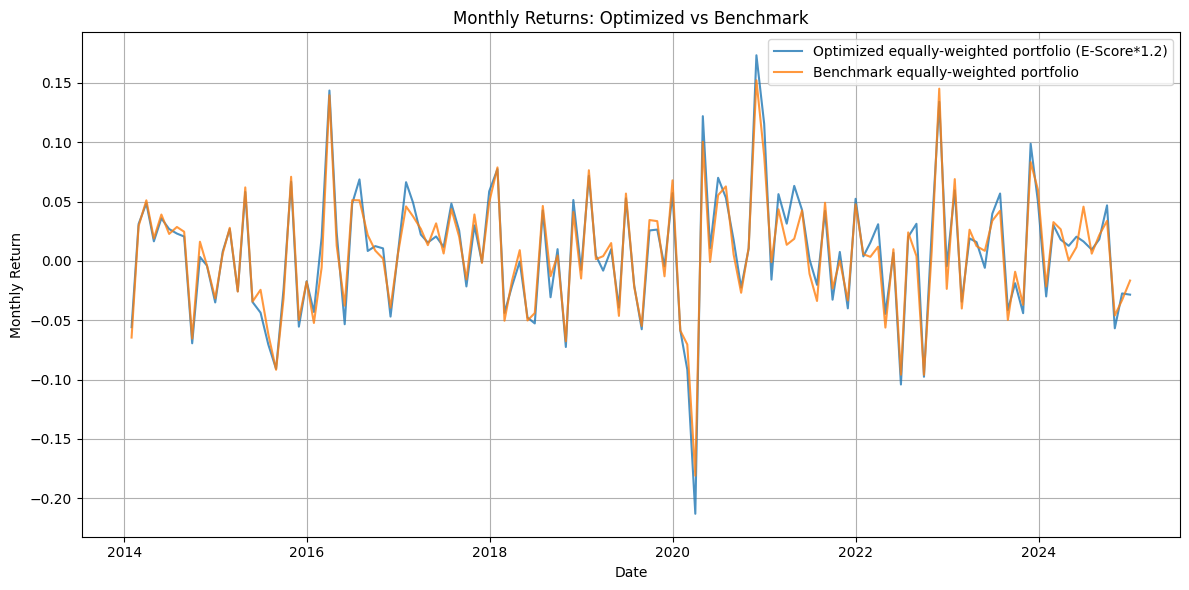

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(opt_returns_series, label='Optimized equally-weighted portfolio (E-Score*1.2)', alpha=0.8)
plt.plot(bench_returns_series, label='Benchmark equally-weighted portfolio', alpha=0.8)
plt.title('Monthly Returns: Optimized vs Benchmark')
plt.xlabel('Date')
plt.ylabel('Monthly Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
opt_returns_series

,0
2014-01-31,-0.055864
2014-02-28,0.031083
2014-03-31,0.048570
2014-04-30,0.016495
2014-05-30,0.035842
...,...
2024-08-30,0.018191
2024-09-30,0.046810
2024-10-31,-0.056816
2024-11-29,-0.027442


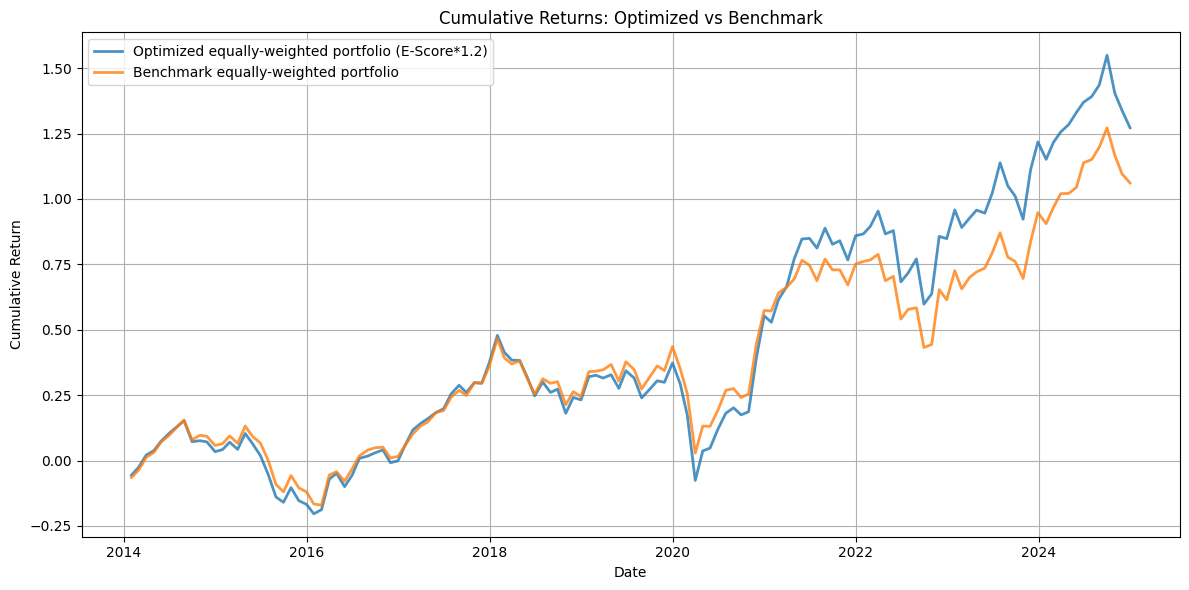

In [ ]:
cumulative_opt = (1 + opt_returns_series).cumprod() -1
cumulative_bench = (1 + bench_returns_series).cumprod() -1

plt.figure(figsize=(12, 6))
plt.plot(cumulative_opt, label='Optimized equally-weighted portfolio (E-Score*1.2)', alpha=0.8, linewidth =2)
plt.plot(cumulative_bench, label='Benchmark equally-weighted portfolio', alpha=0.8, linewidth =2)
plt.title('Cumulative Returns: Optimized vs Benchmark')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


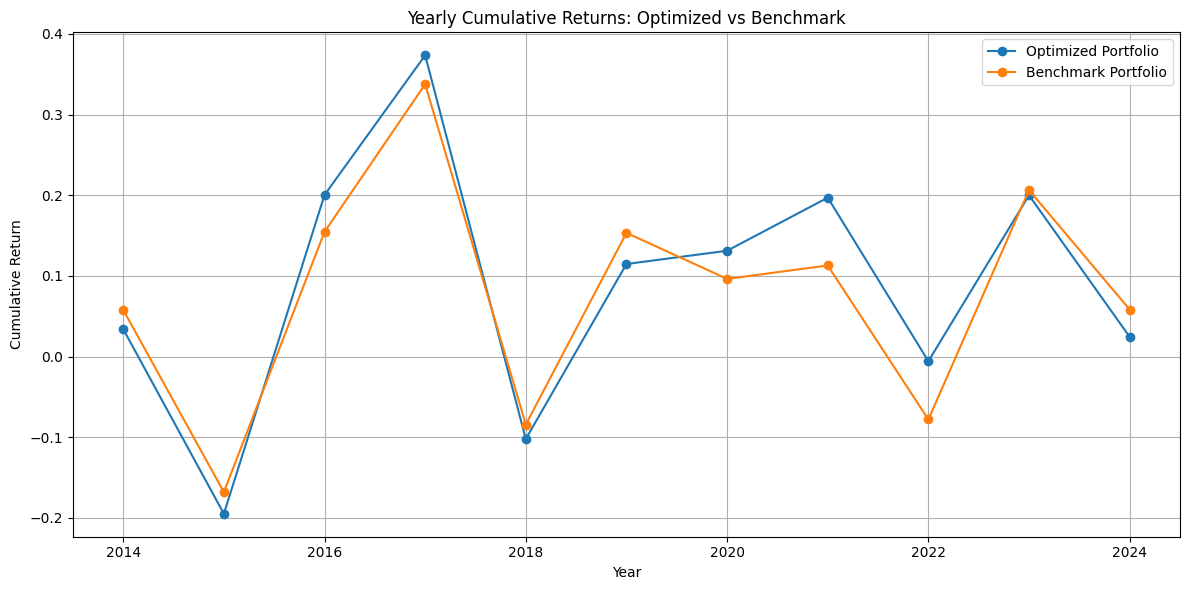

In [ ]:
# Convert to yearly cumulative returns
yearly_opt = (1 + opt_returns_series).groupby(opt_returns_series.index.year).prod() - 1
yearly_bench = (1 + bench_returns_series).groupby(bench_returns_series.index.year).prod() - 1

# Plot
plt.figure(figsize=(12, 6))
plt.plot(yearly_opt, label='Optimized Portfolio', marker='o')
plt.plot(yearly_bench, label='Benchmark Portfolio', marker='o')
plt.title('Yearly Cumulative Returns: Optimized vs Benchmark')
plt.xlabel('Year')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# prompt: can you find the companies with contribute the most to this weights_opt, and find their names via the ISIN in the df returns

# Assuming optimized_weights_by_year is a dictionary with year as keys and pd.Series as values
# where the series contains the weights of each company in that year, indexed by ISIN.
# We also assume returns has an ISIN column with the company ISIN.

# Example: Get the most important company in 2023
year_to_check = 2023
if year_to_check in optimized_weights_by_year:
  weights_opt = optimized_weights_by_year[year_to_check]
  most_important_isin = weights_opt.idxmax()

  # Find company name using the ISIN
  company_name = returns[returns['ISIN'] == most_important_isin]['Name'].values

  if len(company_name) > 0:
    print(f"In {year_to_check}, the company with the highest contribution to the portfolio is: {company_name[0]} (ISIN: {most_important_isin})")
  else:
    print(f"ISIN {most_important_isin} not found in the returns dataframe")
else:
  print(f"No optimized weights found for the year {year_to_check}.")


# To find the top N companies with the highest contributions, you can use nlargest()
def find_top_n_companies(year, n=5):
  if year in optimized_weights_by_year:
    weights_opt = optimized_weights_by_year[year]
    top_n_isins = weights_opt.nlargest(n).index.tolist()

    for isin in top_n_isins:
      company_name = returns[returns['ISIN'] == isin]['Name'].values
      if len(company_name) > 0:
        print(f"In {year}, {company_name[0]} (ISIN: {isin}) has a weight of {weights_opt[isin]}")
      else:
        print(f"ISIN {isin} not found in the returns dataframe")
  else:
    print(f"No optimized weights found for the year {year}.")


# Example: Find the top 3 companies in 2023
find_top_n_companies(2020, n=10)

In 2023, the company with the highest contribution to the portfolio is: TATA MOTORS (ISIN: INE155A01022)
In 2020, AUO (ISIN: TW0002409000) has a weight of 0.005094622055486608
In 2020, LARSEN & TOUBRO (ISIN: INE018A01030) has a weight of 0.0050929923543384294
In 2020, TATA MOTORS (ISIN: INE155A01022) has a weight of 0.004974858157349234
In 2020, MAHINDRA & MAHINDRA (ISIN: INE101A01026) has a weight of 0.004903162137355289
In 2020, UNI-PRESIDENT ENTS. (ISIN: TW0001216000) has a weight of 0.004862618225047409
In 2020, COWAY (ISIN: KR7021240007) has a weight of 0.004851125977488678
In 2020, FAR EASTERN DEPT.STRS. (ISIN: TW0002903002) has a weight of 0.004724255519763288
In 2020, E SUN FINL.HLDG. (ISIN: TW0002884004) has a weight of 0.004708423514958537
In 2020, YUANTA FINANCIAL HDG. (ISIN: TW0002885001) has a weight of 0.004661918645759879
In 2020, TATUNG (ISIN: TW0002371002) has a weight of 0.00464692122262792


In [ ]:
df = pd.DataFrame({'opt_returns_series': opt_returns_series, 'benchmark_return_series': bench_returns_series})
df

,opt_returns_series,benchmark_return_series
2014-01-31,-0.055864,-0.064635
2014-02-28,0.031083,0.029329
2014-03-31,0.048570,0.051074
2014-04-30,0.016495,0.018972
2014-05-30,0.035842,0.039074
...,...,...
2024-08-30,0.018191,0.021739
2024-09-30,0.046810,0.033744
2024-10-31,-0.056816,-0.046021
2024-11-29,-0.027442,-0.033098


In [ ]:
risk_free_rate

,date,RF,year_month
0,2000-01-31,0.0041,2000-01
1,2000-02-29,0.0043,2000-02
2,2000-03-31,0.0047,2000-03
3,2000-04-30,0.0046,2000-04
4,2000-05-31,0.0050,2000-05
...,...,...,...
295,2024-08-31,0.0048,2024-08
296,2024-09-30,0.0040,2024-09
297,2024-10-31,0.0039,2024-10
298,2024-11-30,0.0040,2024-11


In [ ]:
returns_df = df.copy()

#num_assets_per_month = simple_returns_M_2014_2024_prev.count(axis=0) # count total number of companies (N) in the previous month

#total_market_cap_df = total_market_cap_per_month.reset_index()
#total_market_cap_df.columns = ['date', 'market_cap_total_prev_month']

#returns_df = pd.merge(returns_df, total_market_cap_df, on='date', how='left')

# Number of assets based on market cap
#num_assets_per_month_df = num_assets_per_month.reset_index()
#num_assets_per_month_df.columns = ['date', 'num_assets_per_month']

#returns_df = pd.merge(returns_df, num_assets_per_month_df, on='date', how='left')

# Number of assets based on return data
#num_assets_per_month_return_data = simple_returns_M_2014_2024.count(axis=0)

#num_assets_per_month_return_data_df = num_assets_per_month_return_data.reset_index()
#num_assets_per_month_return_data_df.columns = ['date', 'num_assets_per_month_return_data']

#returns_df = pd.merge(returns_df, num_assets_per_month_return_data_df, on='date', how='left')

# Add risk free rate to df
returns_df['year_month'] = returns_df.index.to_period('M').astype(str)

risk_free_rate['year_month'] = risk_free_rate['date'].dt.to_period('M').astype(str)

returns_df = pd.merge(returns_df, risk_free_rate[['year_month', 'RF']], on='year_month', how='left')

# Adding squared difference to df
ew_return_average = returns_df['opt_returns_series'].mean()
vw_return_average = returns_df['benchmark_return_series'].mean()

if 'ew_squared_difference_ew'not in returns_df.columns:
  returns_df['ew_squared_difference'] = ((returns_df['opt_returns_series'] - ew_return_average) ** 2)
if 'vw_squared_difference_vw'not in returns_df.columns:
  returns_df['vw_squared_difference'] = ((returns_df['benchmark_return_series'] - vw_return_average) ** 2)

# Adding cumulative returns to df
if 'ew_cumulative_returns'not in returns_df.columns:
  returns_df['ew_cumulative_returns'] = ((1 + returns_df['opt_returns_series']).cumprod() - 1)
if 'vw_cumulative_returns'not in returns_df.columns:
  returns_df['vw_cumulative_returns'] = ((1 + returns_df['benchmark_return_series']).cumprod() - 1)

if 'rf_cumulative_returns'not in returns_df.columns:
  returns_df['rf_cumulative_returns'] = ((1 + returns_df['RF']).cumprod() - 1)


returns_df

,opt_returns_series,benchmark_return_series,year_month,RF,ew_squared_difference,vw_squared_difference,ew_cumulative_returns,vw_cumulative_returns,rf_cumulative_returns
0,-0.055864,-0.064635,2014-01,0.0000,0.004026,0.005083,-0.055864,-0.064635,0.000000
1,0.031083,0.029329,2014-02,0.0000,0.000552,0.000514,-0.026518,-0.037201,0.000000
2,0.048570,0.051074,2014-03,0.0000,0.001679,0.001973,0.020764,0.011972,0.000000
3,0.016495,0.018972,2014-04,0.0000,0.000079,0.000152,0.037602,0.031171,0.000000
4,0.035842,0.039074,2014-05,0.0000,0.000798,0.001051,0.074791,0.071463,0.000000
...,...,...,...,...,...,...,...,...,...
127,0.018191,0.021739,2024-08,0.0048,0.000112,0.000227,1.435357,1.197874,0.164355
128,0.046810,0.033744,2024-09,0.0040,0.001538,0.000734,1.549357,1.272039,0.169012
129,-0.056816,-0.046021,2024-10,0.0039,0.004148,0.002775,1.404513,1.167477,0.173571
130,-0.027442,-0.033098,2024-11,0.0040,0.001227,0.001581,1.338528,1.095738,0.178265


In [ ]:
total_return = (1 + returns_df['opt_returns_series']).prod() - 1  # Cumulative product of returns

# Step 2: Count total months in the dataset
N = len(returns_df)

# Step 3: Annualize the return
ew_annualized_return = (1 + total_return) ** (12 / N) - 1

print(f"Annualized return of the opt_returns_series: {ew_annualized_return:.6f}")

Annualized return of the opt_returns_series: 0.077459


In [ ]:
total_return = (1 + returns_df['benchmark_return_series']).prod() - 1  # Cumulative product of returns

# Step 2: Count total months in the dataset
N = len(returns_df)

# Step 3: Annualize the return
vw_annualized_return = (1 + total_return) ** (12 / N) - 1

print(f"Annualized return of the benchmark_return_series: {vw_annualized_return:.6f}")

Annualized return of the benchmark_return_series: 0.067954


In [ ]:
min_ew_return = returns_df['opt_returns_series'].min()
print(f"Minimum retrun in the equally weighted portfolio: {min_ew_return}")

Minimum retrun in the equally weighted portfolio: -0.21318611362055415


In [ ]:
min_vw_return = returns_df['benchmark_return_series'].min()
print(f"Minimum retrun in the value weighted portfolio: {min_vw_return}")

Minimum retrun in the value weighted portfolio: -0.18110584733331359


In [ ]:
max_ew_return = returns_df['opt_returns_series'].max()
print(f"Maximum retrun in the equally weighted portfolio: {max_ew_return}")

Maximum retrun in the equally weighted portfolio: 0.17334243011908917


In [ ]:
max_vw_return = returns_df['benchmark_return_series'].max()
print(f"Maximum retrun in the value weighted portfolio: {max_vw_return}")

Maximum retrun in the value weighted portfolio: 0.15226409658526646


In [ ]:
# Compute sample variance (N-1 for unbiased estimator)
ew_variance = returns_df['ew_squared_difference'].sum() / (len(returns_df))

# Convert variance to standard deviation (monthly volatility)
ew_volatility = np.sqrt(ew_variance)

# Annualize volatility (since returns are monthly, use sqrt(12))
ew_volatility_annualized = ew_volatility * np.sqrt(12)

# Print results
print(f"Annualized volatility of the equally-weighted portfolio: {ew_volatility_annualized}")

Annualized volatility of the equally-weighted portfolio: 0.17952778817091355


In [ ]:
# Compute sample variance (N-1 for unbiased estimator)
vw_variance = returns_df['vw_squared_difference'].sum() / (len(returns_df))

# Convert variance to standard deviation (monthly volatility)
vw_volatility = np.sqrt(vw_variance)

# Annualize volatility (since returns are monthly, use sqrt(12))
vw_volatility_annualized = vw_volatility * np.sqrt(12)

# Print results
print(f"Annualized volatility of the value-weighted portfolio: {vw_volatility_annualized}")

Annualized volatility of the value-weighted portfolio: 0.16719614269506522


In [ ]:
df = returns_df

df['ew_excess_return'] = df['opt_returns_series'] - df['RF']

# Calculate Sharpe Ratio
mean_excess_return = df['ew_excess_return'].mean()
std_excess_return = df['ew_excess_return'].std()

ew_sharpe_ratio = mean_excess_return / std_excess_return

print(f"Sharpe Ratio: {ew_sharpe_ratio:.4f}")

Sharpe Ratio: 0.1213


In [ ]:
ew_annualized_sharpe_ratio = ew_sharpe_ratio * np.sqrt(12)
print(f"Annualized Sharpe Ratio: {ew_annualized_sharpe_ratio:.4f}")

Annualized Sharpe Ratio: 0.4202


In [ ]:
df = returns_df

df['vw_excess_return'] = df['benchmark_return_series'] - df['RF']

# Calculate Sharpe Ratio
mean_excess_return = df['vw_excess_return'].mean()
std_excess_return = df['vw_excess_return'].std()

vw_sharpe_ratio = mean_excess_return / std_excess_return

print(f"Sharpe Ratio: {vw_sharpe_ratio:.4f}")

Sharpe Ratio: 0.1112


In [ ]:
vw_annualized_sharpe_ratio = vw_sharpe_ratio * np.sqrt(12)
print(f"Annualized Sharpe Ratio: {vw_annualized_sharpe_ratio:.4f}")

Annualized Sharpe Ratio: 0.3852


In [ ]:
data = {
    'Portfolio': ['Optimized equally-weighted portfolio', 'Benchmark equally-weighted portfolio'],
    'Annualized Return': [ew_annualized_return, vw_annualized_return],  # Replace with actual values
    'Minimum Return': [min_ew_return, min_vw_return],
    'Maximum Return': [max_ew_return, max_vw_return],
    'Annualized Volatility': [ew_volatility_annualized, vw_volatility_annualized],
    'Annualized Sharpe Ratio': [ew_annualized_sharpe_ratio, vw_annualized_sharpe_ratio]
}

df = pd.DataFrame(data)
summary_df = df

summary_df

,Portfolio,Annualized Return,Minimum Return,Maximum Return,Annualized Volatility,Annualized Sharpe Ratio
0,Optimized equally-weighted portfolio,0.077459,-0.213186,0.173342,0.179528,0.420230
1,Benchmark equally-weighted portfolio,0.067954,-0.181106,0.152264,0.167196,0.385165


# Homework 1 Question 2

In [ ]:
risk_free_rate_df = risk_free_rate.copy()
risk_free_rate_df

,date,RF,year_month
0,2000-01-31,0.0041,2000-01
1,2000-02-29,0.0043,2000-02
2,2000-03-31,0.0047,2000-03
3,2000-04-30,0.0046,2000-04
4,2000-05-31,0.0050,2000-05
...,...,...,...
295,2024-08-31,0.0048,2024-08
296,2024-09-30,0.0040,2024-09
297,2024-10-31,0.0039,2024-10
298,2024-11-30,0.0040,2024-11


In [ ]:
df = market_cap_M_no_zeros.copy()

df = df.iloc[:, 2:]

df.columns = pd.to_datetime(df.columns, errors='ignore')

start_date = pd.to_datetime('2013-12-31 00:00:00')
end_date = pd.to_datetime('2024-11-29 00:00:00')

df_2009_2024 = df.loc[:, start_date:end_date]

DS_MV_USD_M_2014_2024 = df_2009_2024

DS_MV_USD_M_2014_2024

<ipython-input-155-4f2532edd0dd>:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df.columns = pd.to_datetime(df.columns, errors='ignore')


,2013-12-31,2014-01-31,2014-02-28,2014-03-31,2014-04-30,2014-05-30,2014-06-30,2014-07-31,2014-08-29,2014-09-30,...,2024-02-29,2024-03-29,2024-04-30,2024-05-31,2024-06-28,2024-07-31,2024-08-30,2024-09-30,2024-10-31,2024-11-29
146,114996.59,104071.17,113190.46,117679.20,114417.33,110958.88,112207.74,108525.20,114330.89,102799.57,...,39886.69,39309.19,36938.22,34658.22,32369.65,32280.60,35781.82,37847.65,34407.58,33596.80
147,29634.93,24716.57,25391.21,28952.72,30013.98,29087.67,32305.75,35054.33,44808.42,29594.35,...,33367.76,32411.79,30317.50,29570.88,27558.30,26916.82,28455.29,28602.67,26066.58,23775.07
148,25938.29,22723.27,24593.36,29077.23,31240.11,29269.99,30588.96,32131.64,38395.87,29919.18,...,14699.78,15132.55,14347.73,12805.03,11839.36,11680.45,14669.45,14338.50,13186.18,11236.44
149,18213.15,15577.58,16030.14,17515.29,19714.15,18752.00,21137.78,21370.09,23356.46,20743.13,...,5113.12,5485.47,5479.35,5947.72,6866.89,6268.28,7792.49,7306.66,7623.63,6991.22
150,3070.92,2646.86,2385.18,2719.98,2349.48,2251.76,2205.46,2136.20,2351.37,2281.60,...,1461.17,1819.89,1416.69,1240.83,1109.52,1071.31,1099.16,1262.82,1046.73,866.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,239.61,219.97,236.29,245.64,244.33,273.06,263.71,260.31,258.23,232.88,...,220.68,239.09,248.89,280.70,295.36,388.98,393.90,413.00,427.45,460.04
2561,10704.38,9867.48,10464.15,12009.48,12396.91,12343.29,12869.13,13250.40,13278.13,11564.96,...,7625.44,6996.32,6906.91,7086.12,7760.90,7856.60,8858.64,9105.44,8530.48,8540.85
2562,1534.18,1482.66,1562.70,1471.59,1547.89,1596.54,1700.40,1632.78,1596.26,1295.70,...,2265.43,2363.04,2632.31,2730.05,2762.38,3107.39,2352.88,2507.23,2918.45,2467.31
2563,984.11,815.02,805.68,839.87,836.60,870.75,906.68,945.20,894.82,819.46,...,45.79,39.68,42.32,39.84,48.32,61.15,71.10,70.09,66.52,78.76


In [ ]:
df = simple_returns_no_zeros.copy()

df = df.iloc[:, 4:]

df.columns = pd.to_datetime(df.columns, errors='ignore')

start_date = pd.to_datetime('2014-01-29 00:00:00')
end_date = pd.to_datetime('2024-12-31 00:00:00')

df_2009_2024 = df.loc[:, start_date:end_date]

simple_returns_M_2014_2024 = df_2009_2024

simple_returns_M_2014_2024

<ipython-input-156-303fa50678e7>:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df.columns = pd.to_datetime(df.columns, errors='ignore')


,2014-01-31,2014-02-28,2014-03-31,2014-04-30,2014-05-30,2014-06-30,2014-07-31,2014-08-29,2014-09-30,2014-10-31,...,2024-03-29,2024-04-30,2024-05-31,2024-06-28,2024-07-31,2024-08-30,2024-09-30,2024-10-31,2024-11-29,2024-12-31
0,-0.081488,0.087626,0.039537,-0.021640,-0.030519,0.011256,-0.023384,0.053382,-0.101144,0.035225,...,-0.014473,-0.060544,-0.061723,-0.066038,-0.002754,0.108466,0.057737,-0.090892,-0.023564,-0.060048
1,-0.165964,0.033939,0.158901,0.036656,-0.027553,0.124174,0.085073,0.281583,-0.332351,0.094324,...,-0.021737,-0.064611,-0.024629,-0.044654,-0.023276,0.075064,0.011822,-0.088666,-0.070730,-0.050255
2,-0.121563,0.085193,0.185800,0.077213,-0.060868,0.047383,0.053240,0.197649,-0.219025,0.072200,...,0.030787,-0.050563,-0.106172,-0.069301,-0.004353,0.265222,-0.015599,-0.072711,-0.140684,-0.108998
3,-0.137319,0.029053,0.092648,0.125540,-0.048807,0.127229,0.018894,0.092953,-0.111890,0.105586,...,0.072827,-0.001119,0.085479,0.154542,-0.087171,0.243162,-0.062344,0.043383,-0.061078,-0.007831
4,-0.138089,-0.098876,0.140372,-0.102991,-0.041582,-0.020550,-0.031409,0.100712,-0.029674,0.117397,...,0.245496,-0.221552,-0.124134,-0.105816,-0.034452,0.026009,0.148867,-0.171098,-0.171820,-0.253886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,-0.081956,0.074204,0.039506,-0.005325,0.117630,-0.005184,-0.012862,-0.008018,-0.098141,-0.148107,...,0.082942,0.040944,0.127626,0.080433,0.316925,0.012633,0.048533,0.034932,0.097795,0.007029
512,-0.078198,0.060456,0.183882,0.032279,-0.004325,0.042585,0.029630,0.002107,-0.108775,0.155667,...,-0.082512,0.036311,0.025936,0.095224,0.012335,0.127532,0.070606,-0.063144,0.001226,0.053002
513,-0.069950,0.053963,-0.058240,0.051648,0.031664,0.064829,-0.039706,-0.022358,-0.188283,-0.056349,...,0.052891,0.113964,0.037187,0.011843,0.124900,-0.242873,0.072477,0.164121,-0.154704,-0.170888
514,-0.171951,-0.011345,0.042418,-0.003932,0.040853,-0.025787,0.042429,-0.053211,-0.084204,-0.067614,...,-0.166667,0.000000,0.000000,0.200000,0.333333,0.125000,0.000000,-0.111111,0.250000,0.000000


In [ ]:
#num_assets_per_month = simple_returns_M_2014_2024_prev.count(axis=0) # count total number of companies (N) in the previous month
num_assets_per_month = (DS_MV_USD_M_2014_2024).count(axis=0)

equal_weights_df = pd.DataFrame([1/num_assets_per_month] * simple_returns_M_2014_2024.shape[0]) # create df that has weighting multiplier for the whole df, varying over months

DS_MV_USD_M_2014_2024_modified = DS_MV_USD_M_2014_2024.fillna(0).replace(np.nan, 0).applymap(lambda x: 1 if x != 0 else 0)

#equal_weights_df = equal_weights_df*DS_MV_USD_M_2014_2024_modified

equal_weights_df.columns = simple_returns_M_2014_2024.columns # adjust indices

simple_returns_M_2014_2024.reset_index(drop=True, inplace=True)

equal_weighted_returns_df = simple_returns_M_2014_2024 * equal_weights_df # matrix with the whole equal weighted returns

ew_portfolio_returns = equal_weighted_returns_df.sum(axis=0) # average monthly equal weighted return per month

ew_portfolio_returns = ew_portfolio_returns.reset_index()
ew_portfolio_returns.columns = ['date', 'ew_return']

ew_portfolio_returns

<ipython-input-157-96a4cb1dfbf9>:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  DS_MV_USD_M_2014_2024_modified = DS_MV_USD_M_2014_2024.fillna(0).replace(np.nan, 0).applymap(lambda x: 1 if x != 0 else 0)


,date,ew_return
0,2014-01-31,-0.052115
1,2014-02-28,0.031455
2,2014-03-31,0.045153
3,2014-04-30,0.014796
4,2014-05-30,0.036701
...,...,...
127,2024-08-30,0.023989
128,2024-09-30,0.049573
129,2024-10-31,-0.053653
130,2024-11-29,-0.024783


In [ ]:
total_market_cap_per_month = DS_MV_USD_M_2014_2024.sum(axis=0) # total market cap of previous month (determined by data selection in data frame preparation)

market_cap_divider_df = pd.DataFrame([1/total_market_cap_per_month] * simple_returns_M_2014_2024.shape[0]) # matrix with 1/montly market cap to divide

market_cap_divider_df.reset_index(drop=True, inplace=True)

DS_MV_USD_M_2014_2024.reset_index(drop=True, inplace=True)

value_weights_df = DS_MV_USD_M_2014_2024 * market_cap_divider_df # matrix with monthly weighted assets

simple_returns_M_2014_2024.reset_index(drop=True, inplace=True)

value_weights_df.columns = simple_returns_M_2014_2024.columns # adjusting indices

value_weighted_returns_df = simple_returns_M_2014_2024 * value_weights_df # matrix with the whole value weighted returns

vw_portfolio_returns = value_weighted_returns_df.sum(axis=0) # average monthly value weighted return

vw_portfolio_returns = vw_portfolio_returns.reset_index()
vw_portfolio_returns.columns = ['date', 'vw_return']

vw_portfolio_returns

,date,vw_return
0,2014-01-31,-0.063135
1,2014-02-28,0.029506
2,2014-03-31,0.044034
3,2014-04-30,0.016913
4,2014-05-30,0.038869
...,...,...
127,2024-08-30,0.016769
128,2024-09-30,0.022790
129,2024-10-31,-0.039998
130,2024-11-29,-0.029935


In [ ]:
returns_df = pd.merge(ew_portfolio_returns, vw_portfolio_returns, on='date')

total_market_cap_df = total_market_cap_per_month.reset_index()
total_market_cap_df.columns = ['date', 'market_cap_total_prev_month']

returns_df = pd.merge(returns_df, total_market_cap_df, on='date', how='left')

# Number of assets based on market cap
num_assets_per_month_df = num_assets_per_month.reset_index()
num_assets_per_month_df.columns = ['date', 'num_assets_per_month']

returns_df = pd.merge(returns_df, num_assets_per_month_df, on='date', how='left')

# Number of assets based on return data
num_assets_per_month_return_data = simple_returns_M_2014_2024.count(axis=0)

num_assets_per_month_return_data_df = num_assets_per_month_return_data.reset_index()
num_assets_per_month_return_data_df.columns = ['date', 'num_assets_per_month_return_data']

returns_df = pd.merge(returns_df, num_assets_per_month_return_data_df, on='date', how='left')

# Add risk free rate to df
returns_df['year_month'] = returns_df['date'].dt.to_period('M').astype(str)
risk_free_rate_df['year_month'] = risk_free_rate_df['date'].dt.to_period('M').astype(str)

returns_df = pd.merge(returns_df, risk_free_rate_df[['year_month', 'RF']], on='year_month', how='left')

# Adding squared difference to df
ew_return_average = returns_df['ew_return'].mean()
vw_return_average = returns_df['vw_return'].mean()

if 'ew_squared_difference_ew'not in returns_df.columns:
  returns_df['ew_squared_difference'] = ((returns_df['ew_return'] - ew_return_average) ** 2)
if 'vw_squared_difference_vw'not in returns_df.columns:
  returns_df['vw_squared_difference'] = ((returns_df['vw_return'] - vw_return_average) ** 2)

# Adding cumulative returns to df
if 'ew_cumulative_returns'not in returns_df.columns:
  returns_df['ew_cumulative_returns'] = ((1 + returns_df['ew_return']).cumprod() - 1)
if 'vw_cumulative_returns'not in returns_df.columns:
  returns_df['vw_cumulative_returns'] = ((1 + returns_df['vw_return']).cumprod() - 1)

if 'rf_cumulative_returns'not in returns_df.columns:
  returns_df['rf_cumulative_returns'] = ((1 + returns_df['RF']).cumprod() - 1)


returns_df

,date,ew_return,vw_return,market_cap_total_prev_month,num_assets_per_month,num_assets_per_month_return_data,year_month,RF,ew_squared_difference,vw_squared_difference,ew_cumulative_returns,vw_cumulative_returns,rf_cumulative_returns
0,2014-01-31,-0.052115,-0.063135,4556403.96,512.0,513,2014-01,0.0000,0.003584,0.004836,-0.052115,-0.063135,0.000000
1,2014-02-28,0.031455,0.029506,4695637.76,512.0,513,2014-02,0.0000,0.000562,0.000534,-0.022299,-0.035492,0.000000
2,2014-03-31,0.045153,0.044034,4891459.74,512.0,513,2014-03,0.0000,0.001399,0.001416,0.021848,0.006979,0.000000
3,2014-04-30,0.014796,0.016913,4942844.94,512.0,513,2014-04,0.0000,0.000050,0.000110,0.036966,0.024010,0.000000
4,2014-05-30,0.036701,0.038869,5134606.99,512.0,513,2014-05,0.0000,0.000838,0.001054,0.075025,0.063812,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,2024-08-30,0.023989,0.016769,7722977.49,513.0,513,2024-08,0.0048,0.000264,0.000107,1.460420,1.140041,0.164355
128,2024-09-30,0.049573,0.022790,7873188.78,513.0,513,2024-09,0.0040,0.001749,0.000268,1.582390,1.188812,0.169012
129,2024-10-31,-0.053653,-0.039998,7553883.76,513.0,513,2024-10,0.0039,0.003771,0.002153,1.443837,1.101264,0.173571
130,2024-11-29,-0.024783,-0.029935,7321671.92,513.0,513,2024-11,0.0040,0.001059,0.001321,1.383271,1.038364,0.178265


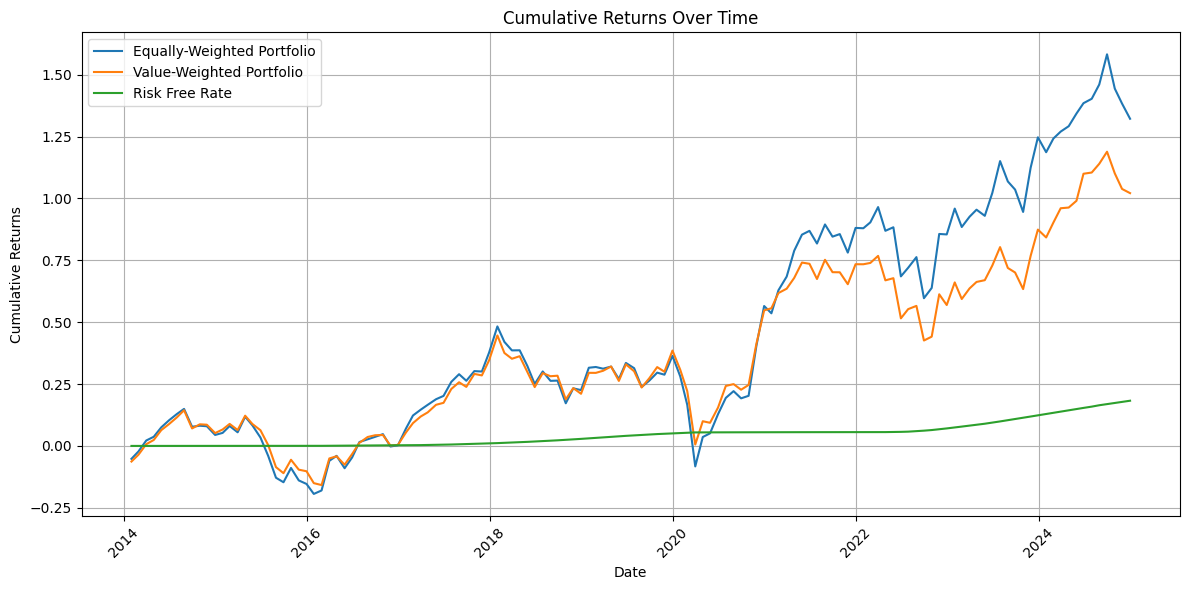

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(returns_df.date, returns_df.ew_cumulative_returns, label='Equally-Weighted Portfolio')
plt.plot(returns_df.date, returns_df.vw_cumulative_returns, label='Value-Weighted Portfolio')
plt.plot(returns_df.date, returns_df.rf_cumulative_returns, label='Risk Free Rate')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.title('Cumulative Returns Over Time')
plt.grid(True)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.legend()  # Add the legend
plt.show()

In [ ]:
total_return = (1 + returns_df['ew_return']).prod() - 1  # Cumulative product of returns

# Step 2: Count total months in the dataset
N = len(returns_df)

# Step 3: Annualize the return
ew_annualized_return = (1 + total_return) ** (12 / N) - 1

print(f"Annualized return of the equally weighted portfolio: {ew_annualized_return:.6f}")


Annualized return of the equally weighted portfolio: 0.079592


In [ ]:
total_return = (1 + returns_df['vw_return']).prod() - 1  # Cumulative product of returns

# Step 2: Count total months in the dataset
N = len(returns_df)

# Step 3: Annualize the return
vw_annualized_return = (1 + total_return) ** (12 / N) - 1

print(f"Annualized return of the value weighted portfolio: {vw_annualized_return:.6f}")

Annualized return of the value weighted portfolio: 0.066074


In [ ]:
min_ew_return = returns_df['ew_return'].min()
print(f"Minimum retrun in the equally weighted portfolio: {min_ew_return}")

Minimum retrun in the equally weighted portfolio: -0.21361244628959924


In [ ]:
min_vw_return = returns_df['vw_return'].min()
print(f"Minimum retrun in the value weighted portfolio: {min_vw_return}")

Minimum retrun in the value weighted portfolio: -0.17686694597817051


In [ ]:
max_ew_return = returns_df['ew_return'].max()
print(f"Maximum retrun in the equally weighted portfolio: {max_ew_return}")

Maximum retrun in the equally weighted portfolio: 0.16746007276081265


In [ ]:
max_vw_return = returns_df['vw_return'].max()
print(f"Maximum retrun in the value weighted portfolio: {max_vw_return}")

Maximum retrun in the value weighted portfolio: 0.13300290965158412


In [ ]:
# Compute sample variance (N-1 for unbiased estimator)
ew_variance = returns_df['ew_squared_difference'].sum() / (len(returns_df))

# Convert variance to standard deviation (monthly volatility)
ew_volatility = np.sqrt(ew_variance)

# Annualize volatility (since returns are monthly, use sqrt(12))
ew_volatility_annualized = ew_volatility * np.sqrt(12)

# Print results
print(f"Annualized volatility of the equally-weighted portfolio: {ew_volatility_annualized}")

Annualized volatility of the equally-weighted portfolio: 0.17932263769163445


In [ ]:
# Compute sample variance (N-1 for unbiased estimator)
vw_variance = returns_df['vw_squared_difference'].sum() / (len(returns_df))

# Convert variance to standard deviation (monthly volatility)
vw_volatility = np.sqrt(vw_variance)

# Annualize volatility (since returns are monthly, use sqrt(12))
vw_volatility_annualized = vw_volatility * np.sqrt(12)

# Print results
print(f"Annualized volatility of the value-weighted portfolio: {vw_volatility_annualized}")

Annualized volatility of the value-weighted portfolio: 0.15908600473055481


In [ ]:
df = returns_df

df['ew_excess_return'] = df['ew_return'] - df['RF']

# Calculate Sharpe Ratio
mean_excess_return = df['ew_excess_return'].mean()
std_excess_return = df['ew_excess_return'].std()

ew_sharpe_ratio = mean_excess_return / std_excess_return

print(f"Sharpe Ratio: {ew_sharpe_ratio:.4f}")

Sharpe Ratio: 0.1246


In [ ]:
ew_annualized_sharpe_ratio = ew_sharpe_ratio * np.sqrt(12)
print(f"Annualized Sharpe Ratio: {ew_annualized_sharpe_ratio:.4f}")

Annualized Sharpe Ratio: 0.4316


In [ ]:
df = returns_df

df['vw_excess_return'] = df['vw_return'] - df['RF']

# Calculate Sharpe Ratio
mean_excess_return = df['vw_excess_return'].mean()
std_excess_return = df['vw_excess_return'].std()

vw_sharpe_ratio = mean_excess_return / std_excess_return

print(f"Sharpe Ratio: {vw_sharpe_ratio:.4f}")

Sharpe Ratio: 0.1114


In [ ]:
vw_annualized_sharpe_ratio = vw_sharpe_ratio * np.sqrt(12)
print(f"Annualized Sharpe Ratio: {vw_annualized_sharpe_ratio:.4f}")

Annualized Sharpe Ratio: 0.3858


In [ ]:
data = {
    'Portfolio': ['Equally Weighted', 'Value Weighted'],
    'Annualized Return': [ew_annualized_return, vw_annualized_return],  # Replace with actual values
    'Minimum Return': [min_ew_return, min_vw_return],
    'Maximum Return': [max_ew_return, max_vw_return],
    'Annualized Volatility': [ew_volatility_annualized, vw_volatility_annualized],
    'Annualized Sharpe Ratio': [ew_annualized_sharpe_ratio, vw_annualized_sharpe_ratio]
}

df = pd.DataFrame(data)
summary_df = df

summary_df

,Portfolio,Annualized Return,Minimum Return,Maximum Return,Annualized Volatility,Annualized Sharpe Ratio
0,Equally Weighted,0.079592,-0.213612,0.167460,0.179323,0.431591
1,Value Weighted,0.066074,-0.176867,0.133003,0.159086,0.385751
